# Deep Learning - Clasificación de Lesiones Cutáneas

**Autores:** David Moreda Amezcua , Javier Cerón Contreras, Pedro Martínez Huertas

**Máster en Inteligencia Artificial - Universidad Loyola**

## 1. Análisis Exploratorio del Dataset

Para la clasificación binaria, agrupamos las lesiones según su malignidad:

**Clase 0 - BENIGNO:**
- **ACK** (Actinic Keratosis): Lesión precancerosa
- **NEV** (Nevus): Lunar benigno
- **SEK** (Seborrheic Keratosis): Queratosis seborreica

**Clase 1 - MALIGNO:**
- **BCC** (Basal Cell Carcinoma): Carcinoma basocelular
- **MEL** (Melanoma): Melanoma maligno
- **SCC** (Squamous Cell Carcinoma): Carcinoma escamoso

**Distribución del dataset:**
- **Train**: 630 imágenes (~364 benignas, ~266 malignas)
- **Test**: 161 imágenes (~89 benignas, ~72 malignas)

**Características de las imágenes:**
- Tamaño medio: ~890x890 píxeles
- Tamaño mínimo: ~147x147 píxeles  
- Tamaño máximo: ~3474x3476 píxeles
- Al tener proporciones similares, hacemos resize directo a 224x224

**Estrategia a seguir:**
1. Data augmentation para aumentar variabilidad
2. Class weights para compensar el desbalance
3. Priorizar recall de malignos (mejor detectar de más que perder un cáncer)

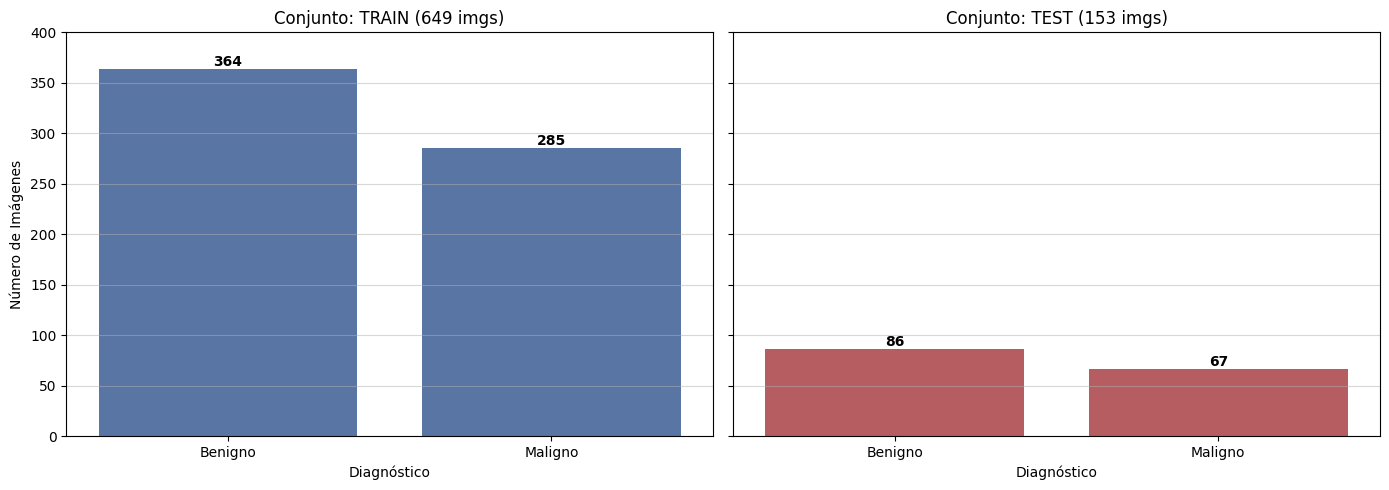


Resumen de Tamaños:
Medio: 890x890
Mínimo: 147x147
Máximo: 3474x3476


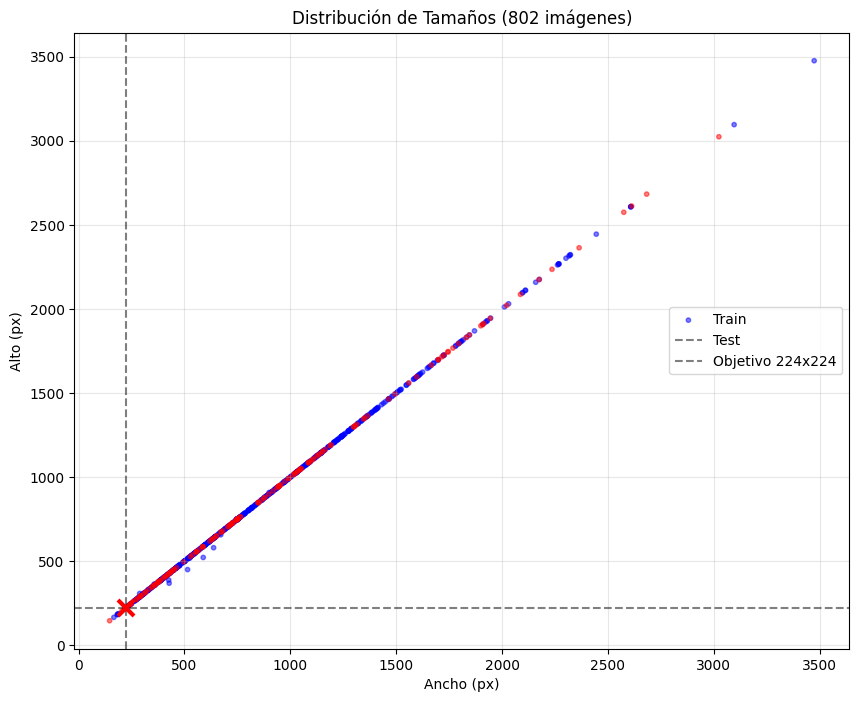

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from tqdm import tqdm

RUTA_RAIZ = "../../Datos/images/SPLIT_BINARIO"
splits = ["train", "test"]
colores = ["#4c72b0", "#c44e52"]

# --- Distribución de clases ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, split in enumerate(splits):
    split_path = os.path.join(RUTA_RAIZ, split)
    clases = sorted(os.listdir(split_path))
    conteo = {c: len(os.listdir(os.path.join(split_path, c))) for c in clases}
    total = sum(conteo.values())

    sns.barplot(x=list(conteo.keys()), y=list(conteo.values()), ax=axes[i], color=colores[i])
    axes[i].set_title(f"Conjunto: {split.upper()} ({total} imgs)")
    axes[i].set_xlabel("Diagnóstico")
    axes[i].grid(axis="y", alpha=0.5)
    axes[i].set_ylim(0, 400) 

    for idx, (clase, valor) in enumerate(conteo.items()):
        axes[i].text(idx, valor + 3, str(valor), ha="center", fontweight="bold")

axes[0].set_ylabel("Número de Imágenes")
plt.tight_layout()
plt.show()

# --- Tamaño de imágenes ---
anchos = []
altos = []
colores_puntos = []
mapa_colores = {"train": "blue", "test": "red"}

for split in splits:
    split_path = os.path.join(RUTA_RAIZ, split)
    clases = sorted(os.listdir(split_path))
    for clase in clases:
        clase_path = os.path.join(split_path, clase)
        archivos = [f for f in os.listdir(clase_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        for nombre in tqdm(archivos, desc=f"{split}/{clase}", leave=False):
            ruta_completa = os.path.join(clase_path, nombre)
            with Image.open(ruta_completa) as img:
                w, h = img.size
                anchos.append(w)
                altos.append(h)
                colores_puntos.append(mapa_colores[split])

plt.figure(figsize=(10, 8))
plt.scatter(anchos, altos, c=colores_puntos, alpha=0.5, s=10)
plt.axvline(224, color="k", linestyle="--", alpha=0.5)
plt.axhline(224, color="k", linestyle="--", alpha=0.5)
plt.plot(224, 224, "rx", markersize=12, markeredgewidth=3)
plt.title(f"Distribución de Tamaños ({len(anchos)} imágenes)")
plt.xlabel("Ancho (px)")
plt.ylabel("Alto (px)")
plt.legend(["Train", "Test", "Objetivo 224x224"])
plt.grid(True, alpha=0.3)

print(f"\nResumen de Tamaños:")
print(f"Medio: {sum(anchos)//len(anchos)}x{sum(altos)//len(altos)}")
print(f"Mínimo: {min(anchos)}x{min(altos)}")
print(f"Máximo: {max(anchos)}x{max(altos)}")

plt.show()


## 2. Búsqueda de Hiperparámetros con Optuna

### Métrica Objetivo

Usamos el **F1-Score de la clase Maligno** como métrica a optimizar. La idea es sencilla: en un problema médico, nos importa más detectar los casos malignos que minimizar las falsas alarmas.

### Metodología

**Validación cruzada con 5 folds:**
- StratifiedKFold para mantener la proporción de clases en cada fold
- Cada trial de Optuna se evalúa como promedio de los 5 folds
- Seed fijo (42) para reproducibilidad

### Modelos y Espacio de Búsqueda

Probamos **20 trials** por modelo con estos hiperparámetros:

**ResNet18 y DenseNet121:**
- `lr_backbone`: [1e-6, 1e-3] (logarítmico)
- `lr_head`: [1e-4, 1e-2] (logarítmico)
- `weight_decay`: [1e-5, 1e-1] (logarítmico)
- `dropout`: [0.0, 0.5]
- `batch_size`: [16, 32]

**YOLO26x:**
- `lr0`: [1e-5, 1e-2] (logarítmico)
- `lrf`: [0.01, 0.2] (fracción final del LR)
- `momentum`: [0.8, 0.98]
- `optimizer`: [SGD, Adam, AdamW]
- `dropout`: [0.0, 0.5]

### Data Augmentation

Para entrenamiento usamos augmentations agresivas:
- Random flip horizontal/vertical (50%)
- HSV jitter (variaciones de color)
- Random scale [0.5, 1.0]
- Random erasing (30%)

Para validación solo resize y normalización ImageNet.

### Class Weights

Calculamos pesos inversamente proporcionales a la frecuencia de cada clase para que el modelo penalice más los errores en la clase minoritaria (maligno).

📊 VISUALIZACIÓN DE HIPERPARAMETRIZACIÓN - TODOS LOS MODELOS

🔍 Cargando estudios de Optuna...
  ✅ ResNet18: 20 trials
  ✅ DenseNet121: 20 trials
  ✅ YOLO26x: 20 trials

📈 Generando gráfica: Evolución de scores...



🎨 Generando gráficas: Combinaciones de hiperparámetros...


  ✅ ResNet18


  ✅ DenseNet121


  ✅ YOLO26x

📊 ESTADÍSTICAS DE TRIALS

     Modelo  Total Trials  Completados  Podados  Fallidos % Completados
   ResNet18            20            9       11         0         45.0%
DenseNet121            20           12        8         0         60.0%
    YOLO26x            20           11        9         0         55.0%

🏆 MEJORES HIPERPARÁMETROS POR MODELO

────────────────────────────────────────────────────────────────────────────────
📌 RESNET18
────────────────────────────────────────────────────────────────────────────────
🏆 Mejor Score: 0.7551
🔢 Mejor Trial: #15

📝 Hiperparámetros:
   • batch_size          : 32
   • dropout             : 0.000000
   • lr_backbone         : 0.000918
   • lr_head             : 0.000124
   • weight_decay        : 0.000630

────────────────────────────────────────────────────────────────────────────────
📌 DENSENET121
────────────────────────────────────────────────────────────────────────────────
🏆 Mejor Score: 0.7592
🔢 Mejor Trial: #8

📝 Hiperp

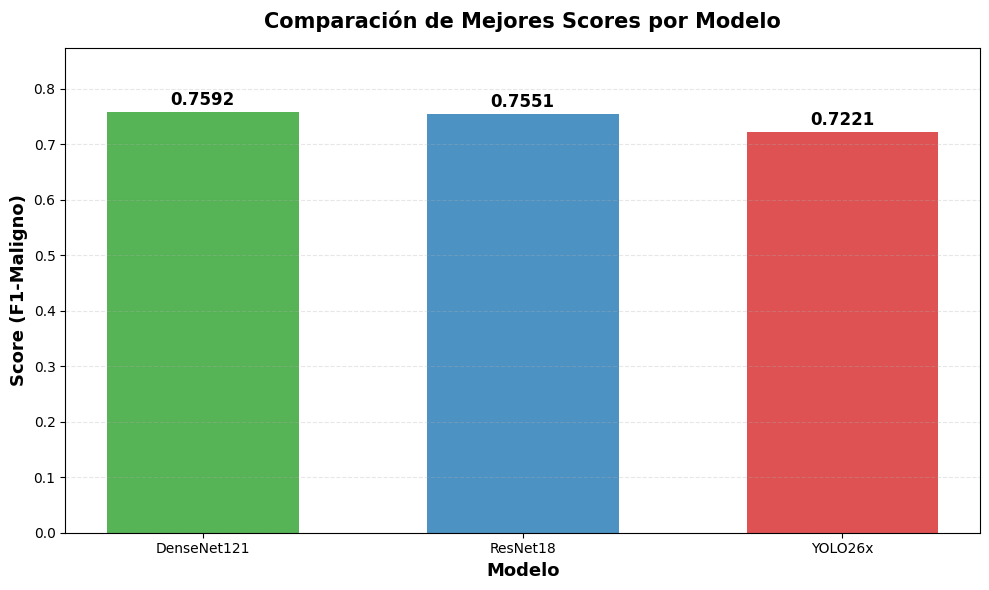


✅ VISUALIZACIÓN COMPLETADA



In [3]:
"""
Visualización de hiperparametrización - ResNet18, DenseNet121, YOLO26x
"""

import optuna
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Configuración
DB_RESNET_DENSENET_YOLO = "hyperparameters/binary_tuning_f1.db"

print("="*80)
print("📊 VISUALIZACIÓN DE HIPERPARAMETRIZACIÓN - TODOS LOS MODELOS")
print("="*80)

# ============================================================================
# 1. CARGAR ESTUDIOS
# ============================================================================

print("\n🔍 Cargando estudios de Optuna...")

storage_res_dense_yolo = f"sqlite:///{DB_RESNET_DENSENET_YOLO}"
try:
    study_resnet = optuna.load_study(study_name="resnet18_binary_f1", storage=storage_res_dense_yolo)
    print(f"  ✅ ResNet18: {len(study_resnet.trials)} trials")
except:
    print(f"  ❌ ResNet18 no encontrado")
    study_resnet = None

try:
    study_densenet = optuna.load_study(study_name="densenet121_binary_f1", storage=storage_res_dense_yolo)
    print(f"  ✅ DenseNet121: {len(study_densenet.trials)} trials")
except:
    print(f"  ❌ DenseNet121 no encontrado")
    study_densenet = None

try:
    study_yolo = optuna.load_study(study_name="yolo_binary_f1", storage=storage_res_dense_yolo)
    print(f"  ✅ YOLO26x: {len(study_yolo.trials)} trials")
except:
    print(f"  ❌ YOLO26x no encontrado")
    study_yolo = None

def get_completed_trials(study):
    if study is None:
        return []
    return [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

# ============================================================================
# 2. GRÁFICA: EVOLUCIÓN DE SCORES
# ============================================================================

print("\n📈 Generando gráfica: Evolución de scores...")

studies = {
    'ResNet18': study_resnet,
    'DenseNet121': study_densenet,
    'YOLO26x': study_yolo
}

colors = {'ResNet18': '#1f77b4', 'DenseNet121': '#2ca02c', 'YOLO26x': '#d62728'}

fig = go.Figure()

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    if not completed:
        continue
    
    trial_numbers = [t.number for t in completed]
    scores = [t.value for t in completed]
    
    # Trials
    fig.add_trace(go.Scatter(
        x=trial_numbers, y=scores,
        mode='markers+lines',
        name=f'{model_name}',
        marker=dict(size=8, color=colors[model_name]),
        line=dict(color=colors[model_name], width=2, dash='dot'),
        opacity=0.6
    ))
    
    # Best so far
    best_so_far = []
    current_best = -float('inf')
    for score in scores:
        current_best = max(current_best, score)
        best_so_far.append(current_best)
    
    fig.add_trace(go.Scatter(
        x=trial_numbers, y=best_so_far,
        mode='lines',
        name=f'{model_name} (best)',
        line=dict(color=colors[model_name], width=3),
        opacity=0.9
    ))

fig.update_layout(
    title='Evolución de Scores en Hiperparametrización',
    xaxis_title='Trial Number',
    yaxis_title='Score (F1- Maligno)',
    hovermode='closest',
    template='plotly_white',
    height=600,
    font=dict(size=12)
)
fig.show()

# ============================================================================
# 3. GRÁFICAS: PARALLEL COORDINATES (Combinaciones de hiperparámetros)
# ============================================================================

print("\n🎨 Generando gráficas: Combinaciones de hiperparámetros...")

for model_name, study in studies.items():
    if study is None or len(get_completed_trials(study)) < 3:
        continue
    
    try:
        fig = optuna.visualization.plot_parallel_coordinate(study)
        fig.update_layout(
            title=f'Combinaciones de Hiperparámetros - {model_name}',
            height=500
        )
        fig.show()
        print(f"  ✅ {model_name}")
    except Exception as e:
        print(f"  ⚠️  Error en {model_name}: {e}")

# ============================================================================
# 4. TABLA: ESTADÍSTICAS DE TRIALS
# ============================================================================

print("\n" + "="*80)
print("📊 ESTADÍSTICAS DE TRIALS")
print("="*80)

stats_data = []

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    total = len(study.trials)
    pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
    failed = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.FAIL)
    
    stats_data.append({
        'Modelo': model_name,
        'Total Trials': total,
        'Completados': len(completed),
        'Podados': pruned,
        'Fallidos': failed,
        '% Completados': f"{len(completed)/total*100:.1f}%"
    })

df_stats = pd.DataFrame(stats_data)
print("\n" + df_stats.to_string(index=False))

# ============================================================================
# 5. RESUMEN: MEJORES HIPERPARÁMETROS
# ============================================================================

print("\n" + "="*80)
print("🏆 MEJORES HIPERPARÁMETROS POR MODELO")
print("="*80)

results_summary = []

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    if not completed:
        continue
    
    best_trial = study.best_trial
    
    print(f"\n{'─'*80}")
    print(f"📌 {model_name.upper()}")
    print(f"{'─'*80}")
    print(f"🏆 Mejor Score: {best_trial.value:.4f}")
    print(f"🔢 Mejor Trial: #{best_trial.number}")
    print(f"\n📝 Hiperparámetros:")
    
    for param, value in sorted(best_trial.params.items()):
        if isinstance(value, float):
            print(f"   • {param:20s}: {value:.6f}")
        else:
            print(f"   • {param:20s}: {value}")
    
    results_summary.append({
        'Modelo': model_name,
        'Score': best_trial.value
    })

# ============================================================================
# 6. GRÁFICA: COMPARACIÓN DE SCORES (MATPLOTLIB)
# ============================================================================

if results_summary:
    print("\n" + "="*80)
    print("📊 COMPARACIÓN FINAL")
    print("="*80)
    
    df = pd.DataFrame(results_summary).sort_values('Score', ascending=False)
    print("\n" + df.to_string(index=False))
    
    # Gráfica con matplotlib
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bar_colors = [colors.get(m, 'gray') for m in df['Modelo']]
    bars = ax.bar(df['Modelo'], df['Score'], color=bar_colors, alpha=0.8, width=0.6)
    
    # Valores encima de barras
    for bar, score in zip(bars, df['Score']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{score:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    ax.set_ylabel('Score (F1-Maligno)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Modelo', fontsize=13, fontweight='bold')
    ax.set_title('Comparación de Mejores Scores por Modelo', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylim(0, max(df['Score']) * 1.15)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("✅ VISUALIZACIÓN COMPLETADA")
print("="*80 + "\n")

### Conclusiones de la Hiperparametrización

#### Ranking de Modelos (F1-Score Maligno)

1. **DenseNet121**: 0.7592 (Trial #8)
2. **ResNet18**: 0.7551 (Trial #15)
3. **YOLO26x**: 0.7221 (Trial #11)

Lo interesante es que DenseNet y ResNet quedan prácticamente empatados (diferencia de 0.5%), mientras que YOLO se queda unos 5 puntos por debajo.

#### Hiperparámetros Óptimos

**DenseNet121** necesita regularización fuerte:
- Dropout 0.5 + weight decay alto (0.057)
- Batch size pequeño (16)
- LR diferenciado: backbone lento (0.0008), head rápido (0.0035)

**ResNet18** funciona mejor sin dropout:
- Sin dropout, weight decay moderado (0.0006)
- Batch size mayor (32)
- LRs más conservadores

**YOLO26x**:
- Dropout 0.5, optimizer Adam
- LR bajo (0.0008), weight decay muy bajo

#### Observaciones

La alta tasa de poda (40-55% de trials) indica que MedianPruner eliminó eficientemente las configuraciones malas. Esto ahorró bastante tiempo de cómputo.

Los patrones de hiperparámetros sugieren que DenseNet, al ser más profundo (121 capas vs 18), necesita más regularización para no sobreajustar en nuestro dataset pequeño.

## 3. Preparación de Datos y 5-Fold Cross-Validation

Ya con los hiperparámetros óptimos, entrenamos cada modelo con 5-Fold CV para evaluar su estabilidad.

**Configuración:**
- Seed fijo (42) para reproducibilidad
- StratifiedKFold para mantener proporción de clases
- Los 3 modelos ven exactamente los mismos folds → comparación justa
- Batch sizes: ResNet=32, DenseNet=16 (según Optuna)

**Métricas a evaluar:**
1. F1-Macro (media de F1 de ambas clases)
2. Estabilidad entre folds (desviación estándar)
3. Recall de la clase maligno

In [2]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
from ultralytics.data.augment import classify_augmentations, classify_transforms
from sklearn.model_selection import StratifiedKFold
import random
import numpy as np

# --- 1. Configuración y Reproductibilidad ---
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

RUTA_BASE = "../../Datos/images/SPLIT_BINARIO"
IMG_SIZE = 224
K_FOLDS = 5
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Definimos los Batch Sizes específicos por modelo
BATCH_SIZES = {
    "resnet18": 32,
    "densenet121": 16
}

# --- 2. Pipelines de Transformación ---
train_pipeline = classify_augmentations(
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    scale=(0.5, 1.0),
    hflip=0.5,
    vflip=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    erasing=0.3,
)

val_test_pipeline = classify_transforms(
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    interpolation="BILINEAR"
)

# --- 3. Dataset Base ---
# Carga inicial para obtener rutas y etiquetas (sin transform aún)
full_train_dataset = datasets.ImageFolder(f"{RUTA_BASE}/train", transform=None)
targets = full_train_dataset.targets
classes = full_train_dataset.classes
print(f"Train total: {len(full_train_dataset)} imgs, Clases: {classes}")

# --- 4. Wrapper para Transformaciones Dinámicas ---
class SubsetConTransform(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = list(indices)
        self.transform = transform

    def __getitem__(self, idx):
        # Obtenemos la imagen original y targets del dataset padre
        img, label = self.dataset[self.indices[idx]]
        # Aplicamos la transformación específica (train o val)
        if self.transform is not None:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.indices)

# --- 5. Pre-cálculo de Folds ---
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
# Convertimos a lista para "congelar" los índices y reusarlos en cada modelo
FOLDS_INDICES = list(skf.split(range(len(targets)), targets))

# --- 6. Funciones Generadoras de DataLoaders ---

def get_fold_loaders(fold_idx, batch_size):
    """
    Crea train_loader y val_loader para un fold específico y un batch_size dado.
    """
    train_idx, val_idx = FOLDS_INDICES[fold_idx]
    
    # Creamos Subsets con sus transformaciones correspondientes
    train_subset = SubsetConTransform(full_train_dataset, train_idx, train_pipeline)
    val_subset = SubsetConTransform(full_train_dataset, val_idx, val_test_pipeline)
    
    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,      # Importante shuffle en train
        num_workers=4,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False,     # No shuffle en val
        num_workers=4,
        pin_memory=True
    )
    
    return train_loader, val_loader

def get_test_loader(batch_size):
    """Genera el loader de test"""
    test_ds = datasets.ImageFolder(f"{RUTA_BASE}/test", transform=val_test_pipeline)
    return DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print("\n✅ Funciones de carga de datos preparadas.")
print(f"  - get_fold_loaders(fold_idx, batch_size) -> train_loader, val_loader")
print(f"  - get_test_loader(batch_size) -> test_loader")

Train total: 649 imgs, Clases: ['Benigno', 'Maligno']

✅ Funciones de carga de datos preparadas.
  - get_fold_loaders(fold_idx, batch_size) -> train_loader, val_loader
  - get_test_loader(batch_size) -> test_loader


### Visualización de Data Augmentation

Veamos cómo quedan las imágenes con las augmentations de entrenamiento:

Visualizando Augmentation para clases: ['Benigno', 'Maligno']


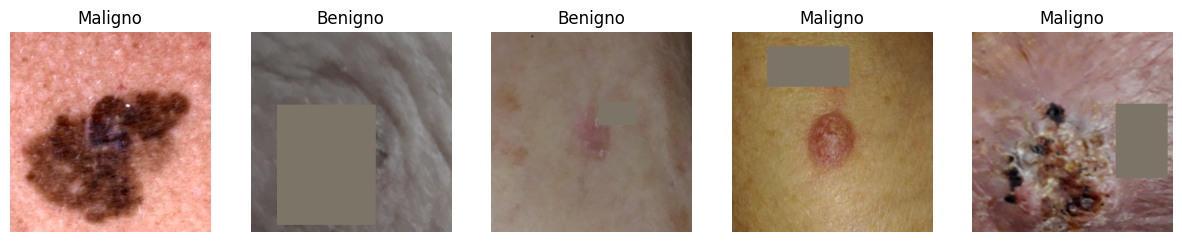

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# 1. Dataset Temporal para Visualización
# Usamos el train_pipeline que definimos antes (con augmentations)
viz_dataset = datasets.ImageFolder(f"{RUTA_BASE}/train", transform=train_pipeline)

# 2. Loader pequeño (batch=5 es suficiente para ver 5 ejemplos)
viz_loader = DataLoader(viz_dataset, batch_size=5, shuffle=True)

# 3. Obtener un batch
imgs, labels = next(iter(viz_loader))

# 4. Función para des-normalizar y pintar
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    # PyTorch es (C, H, W), Matplotlib quiere (H, W, C)
    img = tensor.permute(1, 2, 0).numpy()
    # Deshacer (val - mean) / std  =>  val = img * std + mean
    return np.clip(img * std + mean, 0, 1)

print(f"Visualizando Augmentation para clases: {viz_dataset.classes}")

plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i+1)
    plt.imshow(denormalize(imgs[i]))
    # Usamos las clases del viz_dataset (Benigno/Maligno)
    plt.title(viz_dataset.classes[labels[i]])
    plt.axis("off")
plt.show()

# 5. Limpieza
del viz_dataset, viz_loader

Las augmentations generan variabilidad suficiente (flips, cambios de color, random erasing) mientras mantienen las características importantes de cada lesión. Esto ayuda a prevenir overfitting dado el tamaño pequeño del dataset (649 imágenes).

## 4. Funciones de Entrenamiento y Evaluación

Definimos funciones reutilizables para el entrenamiento de los 3 modelos:

- **Métricas**: F1-macro, F1-weighted, Accuracy, Precision, Recall, Kappa
- **Visualización**: Curvas de entrenamiento, matrices de confusión
- **Pipeline**: Entrenamiento con class weights, guardado del mejor checkpoint por fold

El entrenamiento guarda automáticamente el modelo con mejor F1-Macro en validación.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
import torch
import torch.nn as nn
import pandas as pd
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    accuracy_score, cohen_kappa_score, precision_score, recall_score
)

# ============================================================
# 1. FUNCIONES AUXILIARES DE MÉTRICAS
# ============================================================

def obtener_predicciones(model, loader, device):
    """Obtiene predicciones, etiquetas reales y probabilidades."""
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_probs)

def calcular_metricas(y_true, y_pred):
    """Calcula todas las métricas clave."""
    return {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'kappa': cohen_kappa_score(y_true, y_pred),
    }

def mostrar_reporte_completo(y_true, y_pred, classes, titulo, mostrar_cm=True):
    """Muestra matriz de confusión y reporte detallado."""
    metricas = calcular_metricas(y_true, y_pred)

    if mostrar_cm:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=classes, yticklabels=classes)
        plt.title(f'Matriz de Confusión - {titulo}')
        plt.ylabel('Real')
        plt.xlabel('Predicción')
        plt.show()

    print(f"\n{'='*60}\nREPORTE: {titulo}\n{'='*60}")
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))
    print(f"{'─'*60}")
    print(f"  Accuracy:           {metricas['accuracy']:.4f}")
    print(f"  F1 Macro:           {metricas['f1_macro']:.4f}")
    print(f"  Recall Macro:       {metricas['recall_macro']:.4f}")
    print(f"  Cohen's Kappa:      {metricas['kappa']:.4f}")
    print(f"{'='*60}")
    return metricas


def mostrar_matrices_confusion_folds(predicciones_por_fold, classes, nombre_exp):
    """Muestra las 5 matrices de confusión de validación en una sola figura."""
    n_folds = len(predicciones_por_fold)
    fig, axes = plt.subplots(1, n_folds, figsize=(4*n_folds, 4))
    if n_folds == 1:
        axes = [axes]

    for fold_idx, (y_true, y_pred) in enumerate(predicciones_por_fold):
        cm = confusion_matrix(y_true, y_pred)
        metricas = calcular_metricas(y_true, y_pred)

        ax = axes[fold_idx]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=classes, yticklabels=classes, ax=ax)
        ax.set_title(f'Fold {fold_idx+1}\nF1={metricas["f1_macro"]:.3f} | Acc={metricas["accuracy"]:.3f}')
        ax.set_ylabel('Real' if fold_idx == 0 else '')
        ax.set_xlabel('Predicción')

    plt.suptitle(f'Matrices de Confusión (Validación) - {nombre_exp}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# ============================================================
# 2. FUNCIONES DE VISUALIZACIÓN (HISTORIAL)
# ============================================================

def plot_training_history(historial, titulo=""):
    epochs = range(1, len(historial['train_loss']) + 1)
    plt.figure(figsize=(15, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, historial['train_loss'], label='Train Loss', color='blue')
    plt.plot(epochs, historial['val_loss'], label='Val Loss', color='orange', linestyle='--')
    plt.title(f'Loss - {titulo}')
    plt.xlabel('Épocas'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.3)

    # F1
    plt.subplot(1, 2, 2)
    plt.plot(epochs, historial['val_f1'], label='Val F1 (Macro)', color='green', marker='o')
    plt.axhline(y=max(historial['val_f1']), color='r', linestyle=':', label=f'Best: {max(historial["val_f1"]):.4f}')
    plt.title(f'F1-Score - {titulo}')
    plt.xlabel('Épocas'); plt.ylabel('F1'); plt.legend(); plt.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

def plot_kfold_history(historiales, nombre_exp):
    """Promedia las curvas de los 5 folds."""
    max_epochs = max(len(h['train_loss']) for h in historiales)
    def pad(lst, length): return lst + [lst[-1]] * (length - len(lst))

    train_losses = np.array([pad(h['train_loss'], max_epochs) for h in historiales])
    val_losses = np.array([pad(h['val_loss'], max_epochs) for h in historiales])
    val_f1s = np.array([pad(h['val_f1'], max_epochs) for h in historiales])

    epochs = range(1, max_epochs + 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Loss Plot
    ax = axes[0]
    mean_tl, std_tl = train_losses.mean(0), train_losses.std(0)
    mean_vl, std_vl = val_losses.mean(0), val_losses.std(0)
    ax.plot(epochs, mean_tl, 'b-', label='Train Loss (avg)')
    ax.fill_between(epochs, mean_tl-std_tl, mean_tl+std_tl, alpha=0.2, color='blue')
    ax.plot(epochs, mean_vl, 'r--', label='Val Loss (avg)')
    ax.fill_between(epochs, mean_vl-std_vl, mean_vl+std_vl, alpha=0.2, color='red')
    ax.set_title(f'Loss Promedio - {nombre_exp}'); ax.legend(); ax.grid(True, alpha=0.3)

    # F1 Plot
    ax = axes[1]
    mean_f1, std_f1 = val_f1s.mean(0), val_f1s.std(0)
    ax.plot(epochs, mean_f1, 'g-', label='Val F1 Macro (avg)')
    ax.fill_between(epochs, mean_f1-std_f1, mean_f1+std_f1, alpha=0.2, color='green')
    ax.set_title(f'F1 Promedio - {nombre_exp}'); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

# ============================================================
# 3. BUCLE DE ENTRENAMIENTO (UN FOLD)
# ============================================================

def entrenar_un_fold(model, train_loader, val_loader, criterion, optimizer, device, epochs, nombre_archivo):
    historial = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'train_f1': []}
    best_f1 = 0.0
    best_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # Train
        model.train()
        r_loss = 0.0
        y_true_train, y_pred_train = [], []
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            r_loss += loss.item() * x.size(0)
            _, preds = torch.max(out, 1)
            y_true_train.extend(y.cpu().numpy())
            y_pred_train.extend(preds.cpu().numpy())

        train_loss = r_loss / len(train_loader.dataset)
        train_f1 = f1_score(y_true_train, y_pred_train, average='macro')

        # Val
        model.eval()
        v_loss = 0.0; y_true = []; y_pred = []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                v_loss += loss.item() * x.size(0)
                _, preds = torch.max(out, 1)
                y_true.extend(y.cpu().numpy()); y_pred.extend(preds.cpu().numpy())

        val_loss = v_loss / len(val_loader.dataset)
        val_f1 = f1_score(y_true, y_pred, average='macro')

        historial['train_loss'].append(train_loss)
        historial['train_f1'].append(train_f1)
        historial['val_loss'].append(val_loss)
        historial['val_f1'].append(val_f1)

        msg = ""
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), nombre_archivo)
            msg = " ** Mejor!"

        print(f"  Ep {epoch+1:02d} | T.Loss: {train_loss:.4f} | T.F1: {train_f1:.4f} | V.Loss: {val_loss:.4f} | V.F1: {val_f1:.4f}{msg}")

    model.load_state_dict(best_wts)
    return model, historial

# ============================================================
# 4. PIPELINE PRINCIPAL (SIN EVALUACIÓN EN TEST)
# ============================================================

def lanzar_experimento_kfold(crear_modelo_fn, nombre_exp, device, batch_size, epochs=25):
    """
    Pipeline 5-Fold CV SIN evaluación en TEST.
    La evaluación en test se hace al final del notebook.
    """
    print(f"\n{'='*70}\n EXPERIMENTO 5-FOLD: {nombre_exp} (Batch Size: {batch_size})\n{'='*70}")

    num_classes = len(classes)
    metricas_folds = []
    historiales = []
    modelos_state_dicts = []
    predicciones_val_por_fold = []

    # Acumular predicciones de validación
    y_true_val_todos = []
    y_pred_val_todos = []
    y_probs_val_todos = []

    # --- 1. ENTRENAMIENTO CRUZADO ---
    for fold_idx in range(K_FOLDS):
        print(f"\n FOLD {fold_idx+1}/{K_FOLDS}")

        train_loader, val_loader = get_fold_loaders(fold_idx, batch_size)

        # Pesos de clase
        train_indices = FOLDS_INDICES[fold_idx][0]
        fold_targets = [targets[i] for i in train_indices]
        counts = np.bincount(fold_targets, minlength=num_classes).astype(float)
        weights = 1.0 / counts
        weights = weights / weights.sum() * num_classes
        class_weights = torch.FloatTensor(weights).to(device)

        criterion = nn.CrossEntropyLoss(weight=class_weights)
        model, optimizer = crear_modelo_fn(num_classes, device)

        filename = f"{nombre_exp}_fold{fold_idx+1}.pth"
        model, hist = entrenar_un_fold(model, train_loader, val_loader, criterion, optimizer, device, epochs, filename)

        # Métricas Validación
        yt, yp, yprobs = obtener_predicciones(model, val_loader, device)
        mets = calcular_metricas(yt, yp)

        print(f"   Fin Fold {fold_idx+1}: F1(Macro)={mets['f1_macro']:.4f} | Acc={mets['accuracy']:.4f} | Kappa={mets['kappa']:.4f}")

        metricas_folds.append(mets)
        historiales.append(hist)
        modelos_state_dicts.append(copy.deepcopy(model.state_dict()))
        predicciones_val_por_fold.append((yt, yp))

        # Acumular para evaluación global
        y_true_val_todos.extend(yt)
        y_pred_val_todos.extend(yp)
        y_probs_val_todos.extend(yprobs)

    # --- 2. RESUMEN VALIDACIÓN ---
    print(f"\n{'='*70}\n RESUMEN VALIDACIÓN (CV)\n{'='*70}")
    df = pd.DataFrame(metricas_folds, index=[f"Fold {i+1}" for i in range(K_FOLDS)])
    df.loc['Media'] = df.mean()
    df.loc['Std'] = df.std()
    print(df[['f1_macro', 'accuracy', 'recall_macro', 'kappa']].round(4).to_string())

    print("\n Curvas Promedio:")
    plot_kfold_history(historiales, nombre_exp)

    # Curvas individuales
    for i, h in enumerate(historiales):
        plot_training_history(h, titulo=f"{nombre_exp} - Fold {i+1}")

    # --- 3. MATRICES DE CONFUSIÓN POR FOLD (VALIDACIÓN) ---
    print(f"\n{'='*70}\n MATRICES DE CONFUSIÓN POR FOLD (VALIDACIÓN) - {nombre_exp}\n{'='*70}")
    mostrar_matrices_confusion_folds(predicciones_val_por_fold, classes, nombre_exp)

    # --- 4. EVALUACIÓN GLOBAL EN VALIDACIÓN ---
    print(f"\n{'='*70}\n EVALUACIÓN GLOBAL VALIDACIÓN (todos los folds) - {nombre_exp}\n{'='*70}")

    y_true_val_todos = np.array(y_true_val_todos)
    y_pred_val_todos = np.array(y_pred_val_todos)

    metricas_val_global = mostrar_reporte_completo(
        y_true_val_todos, y_pred_val_todos, classes,
        f"VALIDACIÓN GLOBAL - {nombre_exp}"
    )

    # --- 5. MEJOR FOLD ---
    f1_scores = [m['f1_macro'] for m in metricas_folds]
    best_fold = int(np.argmax(f1_scores))

    print(f"\n{'='*70}")
    print(f"MEJOR FOLD: {best_fold+1} (F1 Macro Val = {f1_scores[best_fold]:.4f})")
    print(f"{'='*70}")

    return {
        'metricas_folds': metricas_folds,
        'df_resumen': df,
        'modelos_state_dicts': modelos_state_dicts,
        'historiales': historiales,
        'predicciones_val_por_fold': predicciones_val_por_fold,
        'metricas_val_global': metricas_val_global,
        'best_fold': best_fold,
        'classes': classes,
        'num_classes': num_classes,
    }

print("Funciones de Entrenamiento cargadas (SIN evaluación en test).")


Funciones de Entrenamiento cargadas (SIN evaluación en test).


## 5. Entrenamiento: ResNet18

### Arquitectura

ResNet18 es una red con 18 capas y conexiones residuales que facilitan el entrenamiento de redes profundas.

**Estrategia de transfer learning:**
- Capas 1-3: congeladas (features genéricos de ImageNet)
- Layer 4: fine-tuning (adaptación a lesiones de piel)
- Cabeza FC: entrenada desde cero (512 → 2 clases)

### Hiperparámetros (Trial #15 de Optuna)

| Parámetro | Valor |
|-----------|-------|
| lr_backbone | 0.000918 |
| lr_head | 0.000124 |
| weight_decay | 0.000630 |
| dropout | 0.0 |
| batch_size | 32 |

La ausencia de dropout es interesante: ResNet18 es suficientemente simple para nuestro dataset y el batch size grande proporciona estabilidad.

Usando device: cuda

 EXPERIMENTO 5-FOLD: ResNet18_Binario_5Fold (Batch Size: 32)

 FOLD 1/5
  Ep 01 | T.Loss: 0.9944 | T.F1: 0.5739 | V.Loss: 1.0743 | V.F1: 0.7154 ** Mejor!
  Ep 02 | T.Loss: 0.6930 | T.F1: 0.6453 | V.Loss: 0.7691 | V.F1: 0.6448
  Ep 03 | T.Loss: 0.5557 | T.F1: 0.7134 | V.Loss: 0.5737 | V.F1: 0.7375 ** Mejor!
  Ep 04 | T.Loss: 0.5084 | T.F1: 0.7526 | V.Loss: 0.5520 | V.F1: 0.7624 ** Mejor!
  Ep 05 | T.Loss: 0.4621 | T.F1: 0.7762 | V.Loss: 0.5927 | V.F1: 0.6991
  Ep 06 | T.Loss: 0.4492 | T.F1: 0.7745 | V.Loss: 0.5957 | V.F1: 0.7379
  Ep 07 | T.Loss: 0.4428 | T.F1: 0.7736 | V.Loss: 0.7873 | V.F1: 0.6299
  Ep 08 | T.Loss: 0.4043 | T.F1: 0.8086 | V.Loss: 0.7416 | V.F1: 0.6911
  Ep 09 | T.Loss: 0.3471 | T.F1: 0.8500 | V.Loss: 0.7422 | V.F1: 0.6846
  Ep 10 | T.Loss: 0.3681 | T.F1: 0.8383 | V.Loss: 0.8387 | V.F1: 0.6683
  Ep 11 | T.Loss: 0.4010 | T.F1: 0.7855 | V.Loss: 1.0224 | V.F1: 0.6876
  Ep 12 | T.Loss: 0.3563 | T.F1: 0.8232 | V.Loss: 0.5613 | V.F1: 0.7842 ** Mejor!
  E

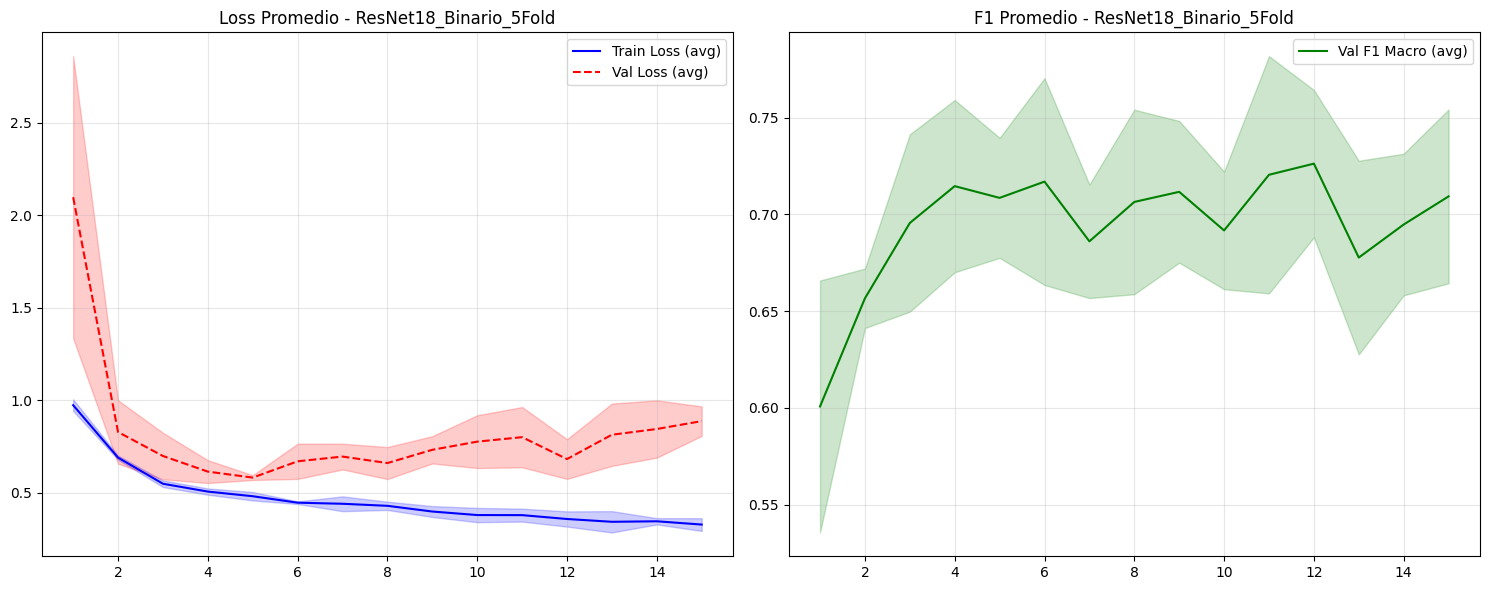

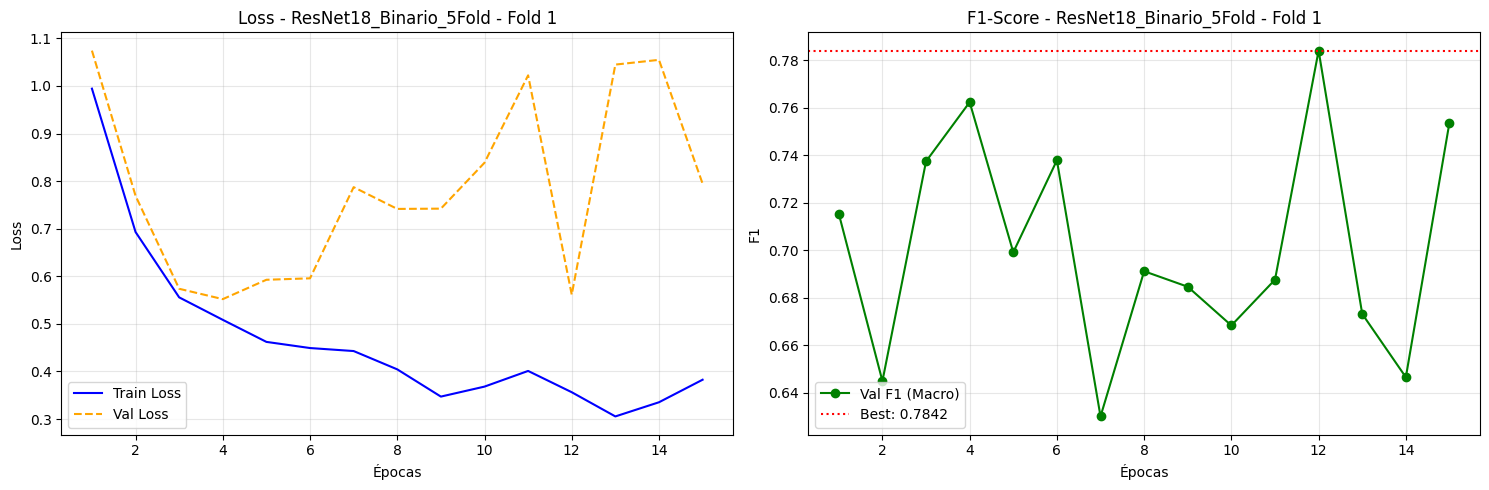

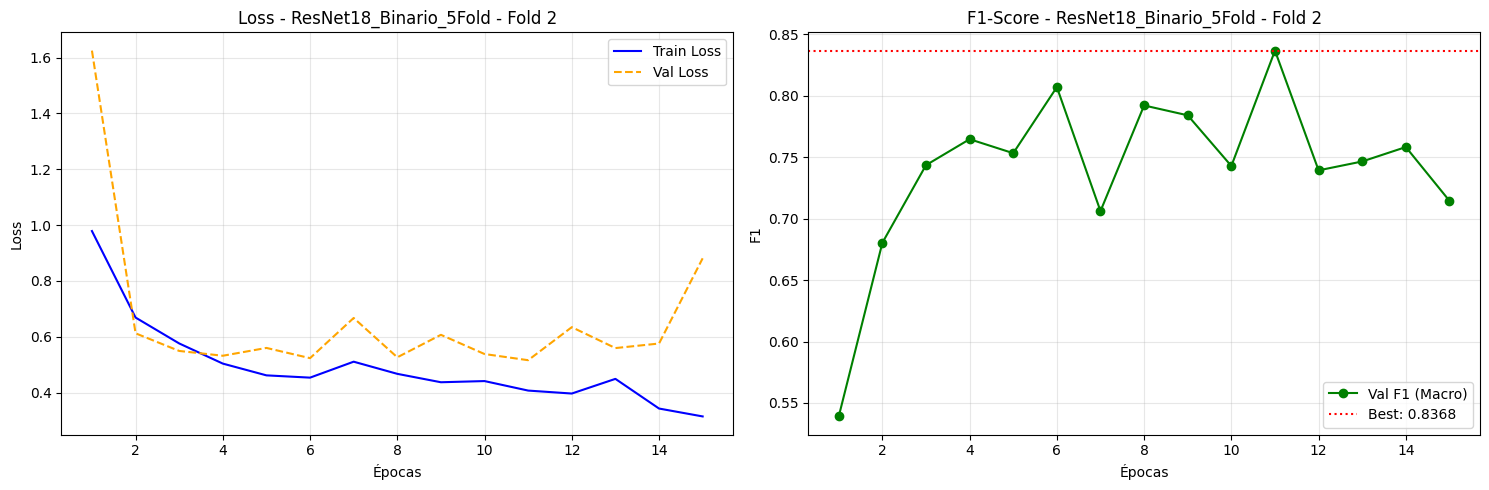

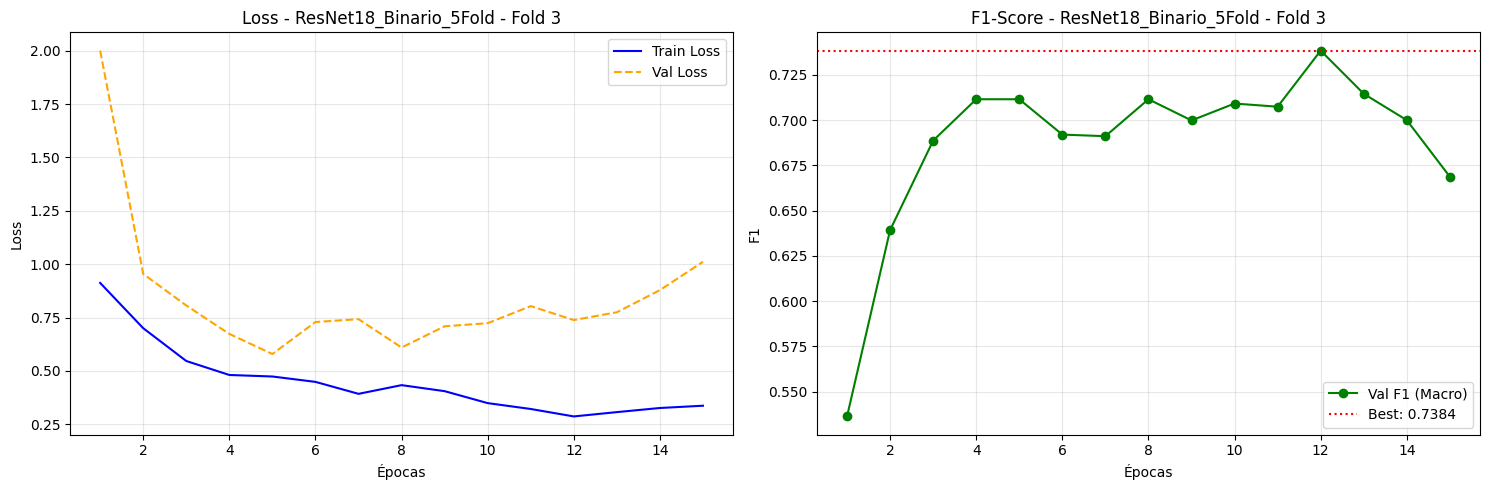

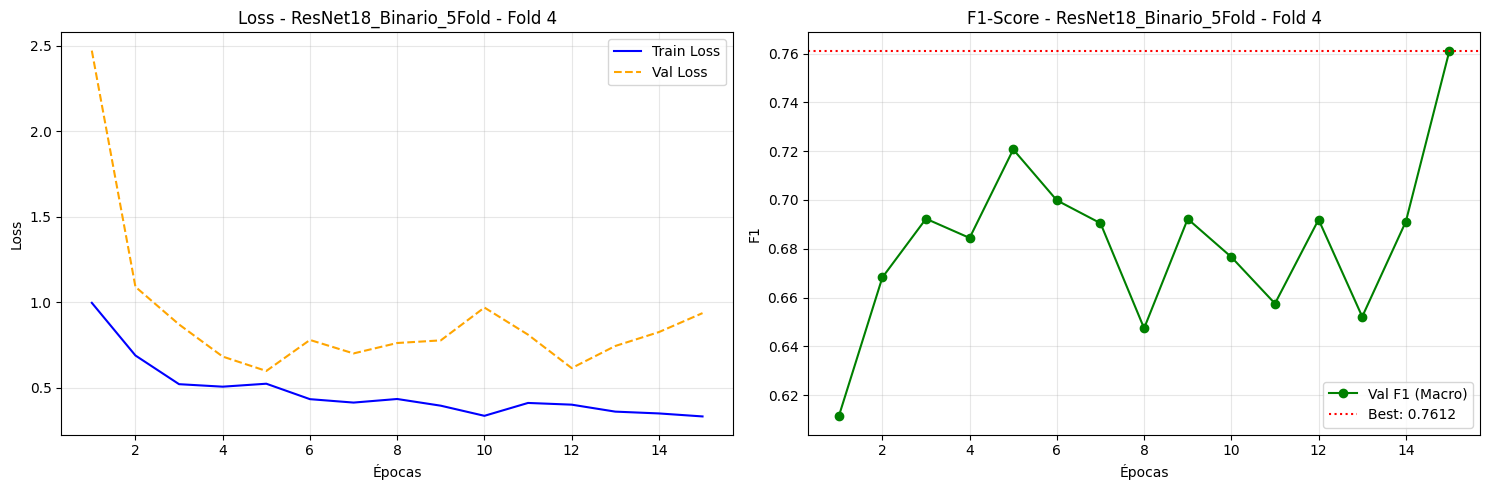

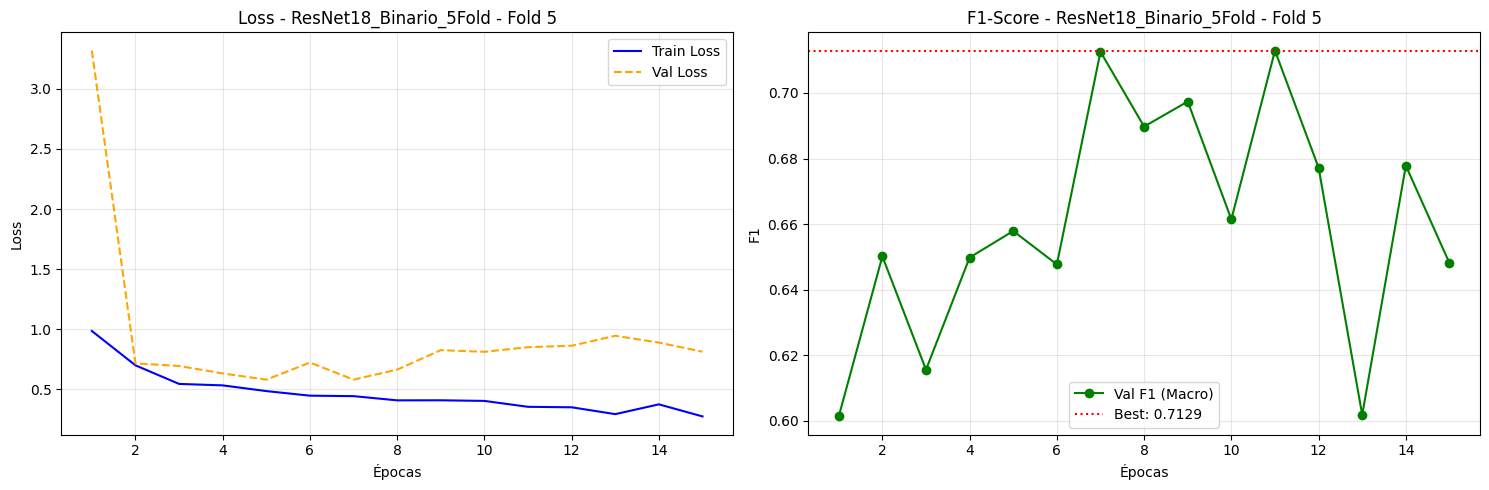


 MATRICES DE CONFUSIÓN POR FOLD (VALIDACIÓN) - ResNet18_Binario_5Fold


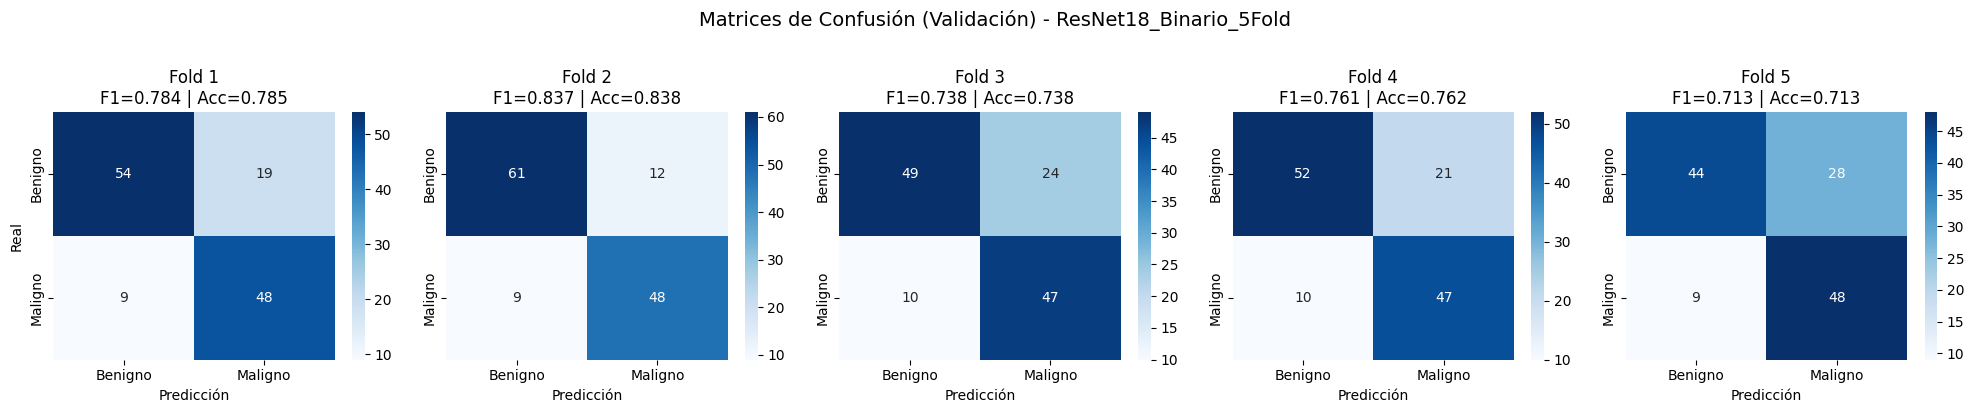


 EVALUACIÓN GLOBAL VALIDACIÓN (todos los folds) - ResNet18_Binario_5Fold


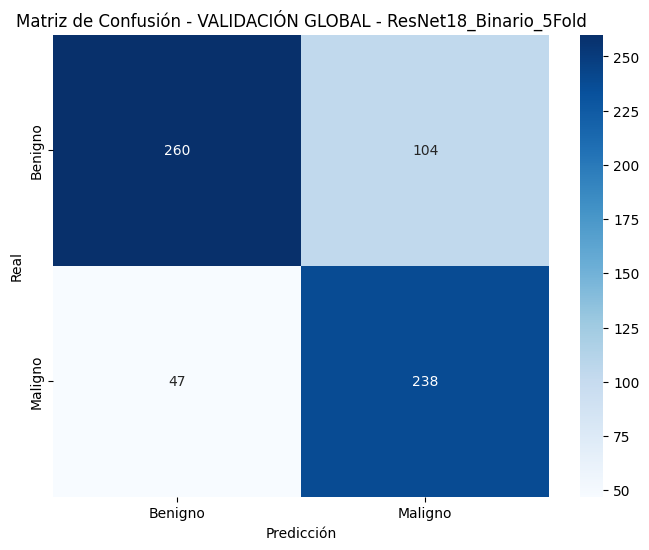


REPORTE: VALIDACIÓN GLOBAL - ResNet18_Binario_5Fold
              precision    recall  f1-score   support

     Benigno       0.85      0.71      0.77       364
     Maligno       0.70      0.84      0.76       285

    accuracy                           0.77       649
   macro avg       0.77      0.77      0.77       649
weighted avg       0.78      0.77      0.77       649

────────────────────────────────────────────────────────────
  Accuracy:           0.7673
  F1 Macro:           0.7671
  Recall Macro:       0.7747
  Cohen's Kappa:      0.5377

MEJOR FOLD: 2 (F1 Macro Val = 0.8368)


In [6]:
import torchvision.models as models
import torch.optim as optim

# Configuramos el dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

# --- Definición de la factoría del modelo ---
# Esta función se llamará al inicio de cada Fold para crear un modelo limpio
def crear_resnet18(num_classes, device):
    # 1. Cargar pesos pre-entrenados
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # 2. Congelar todo el backbone
    for param in model.parameters():
        param.requires_grad = False

    # 3. Descongelar último bloque (Layer 4)
    for param in model.layer4.parameters():
        param.requires_grad = True

    # 4. Nueva cabeza de clasificación binaria
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, num_classes)
    )

    model = model.to(device)

    # 5. Optimizador con Learning Rates diferenciales
    # (Usamos los valores que tenía tu código, pero idealmente vendrían del tuning)
    optimizer = optim.AdamW([
        {'params': model.layer4.parameters(), 'lr': 0.000918},
        {'params': model.fc.parameters(), 'lr': 0.000124}
    ], weight_decay=0.000630)
    
    return model, optimizer

# --- Lanzar el Experimento 5-Fold ---
resultados_resnet = lanzar_experimento_kfold(
    crear_modelo_fn=crear_resnet18,
    nombre_exp="ResNet18_Binario_5Fold",
    device=device,
    batch_size=32,  # <--- Batch Size específico para ResNet
    epochs=15       # Ajusta las épocas según necesites
)

### Resultados del 5-Fold CV

#### Métricas de Validación

| Métrica | Media | Std | Rango |
|---------|-------|-----|-------|
| **F1-Macro** | **0.7667** | 0.0423 | 0.7129 - 0.8368 |
| Accuracy | 0.7673 | 0.0428 | 0.7132 - 0.8385 |
| Recall-Macro | 0.7745 | 0.0386 | 0.7266 - 0.8389 |
| Cohen's Kappa | 0.5383 | 0.0809 | 0.4380 - 0.6738 |

**Mejor Fold:** #2 (F1=0.8368) | **Peor Fold:** #5 (F1=0.7129)

#### Rendimiento por Clase

|  | Precision | Recall | F1-Score |
|--|-----------|--------|----------|
| **Benigno** | 0.85 | 0.71 | 0.77 |
| **Maligno** | 0.70 | **0.84** | 0.76 |

El modelo tiene buen recall de malignos (84%), que es lo que nos interesa. Pierde 47 malignos de 285 (16% de falsos negativos).

#### Análisis

- **Supera la expectativa de Optuna** (+1.5%): esperábamos 0.755, obtuvimos 0.767
- **Recall de maligno es bueno** (84%): el modelo prioriza detectar malignos
- **Variabilidad moderada**: std de 0.042 entre folds, razonable
- **Algo de overfitting**: Train F1 ~0.86 vs Val F1 ~0.77, pero aceptable

## 6. Entrenamiento: DenseNet121

### Arquitectura

DenseNet121 tiene 121 capas con conexiones densas: cada capa recibe features de todas las anteriores. Es más profundo y complejo que ResNet18.

**Transfer learning:**
- DenseBlocks 1-3: congelados
- DenseBlock 4 + Norm5: fine-tuning
- Cabeza: Dropout(0.5) + Linear(1024 → 2)

### Hiperparámetros (Trial #8 de Optuna)

| Parámetro | Valor |
|-----------|-------|
| lr_backbone | 0.000811 |
| lr_head | 0.003550 |
| weight_decay | 0.057279 |
| dropout | 0.5 |
| batch_size | 16 |

DenseNet necesita mucha más regularización que ResNet (dropout 0.5, weight decay alto). Esto tiene sentido: al ser más profundo, tiene más capacidad de sobreajustar.


 EXPERIMENTO 5-FOLD: DenseNet121_Binario_5Fold (Batch Size: 16)

 FOLD 1/5
  Ep 01 | T.Loss: 0.8029 | T.F1: 0.5878 | V.Loss: 0.6124 | V.F1: 0.7150 ** Mejor!
  Ep 02 | T.Loss: 0.7391 | T.F1: 0.6573 | V.Loss: 0.4959 | V.F1: 0.7458 ** Mejor!
  Ep 03 | T.Loss: 0.6500 | T.F1: 0.6734 | V.Loss: 0.5326 | V.F1: 0.7687 ** Mejor!
  Ep 04 | T.Loss: 0.6957 | T.F1: 0.6789 | V.Loss: 0.6584 | V.F1: 0.7071
  Ep 05 | T.Loss: 0.6459 | T.F1: 0.7021 | V.Loss: 0.4560 | V.F1: 0.7624
  Ep 06 | T.Loss: 0.5736 | T.F1: 0.7361 | V.Loss: 0.5431 | V.F1: 0.8077 ** Mejor!
  Ep 07 | T.Loss: 0.5658 | T.F1: 0.7552 | V.Loss: 0.4575 | V.F1: 0.8000
  Ep 08 | T.Loss: 0.5325 | T.F1: 0.7413 | V.Loss: 0.6937 | V.F1: 0.7220
  Ep 09 | T.Loss: 0.5708 | T.F1: 0.7491 | V.Loss: 0.5732 | V.F1: 0.7690
  Ep 10 | T.Loss: 0.4914 | T.F1: 0.7824 | V.Loss: 0.6339 | V.F1: 0.7384
  Ep 11 | T.Loss: 0.4579 | T.F1: 0.7787 | V.Loss: 0.6690 | V.F1: 0.7692
  Ep 12 | T.Loss: 0.4940 | T.F1: 0.7749 | V.Loss: 0.7995 | V.F1: 0.7261
  Ep 13 | T.Loss: 0.

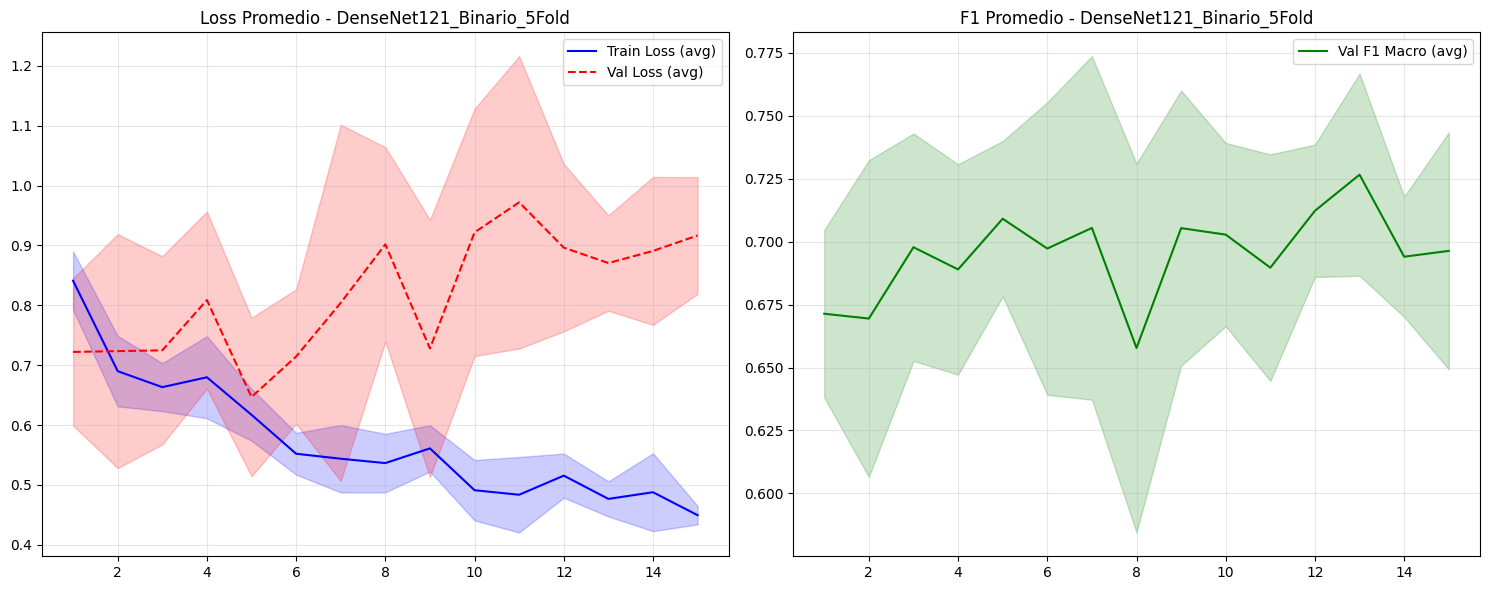

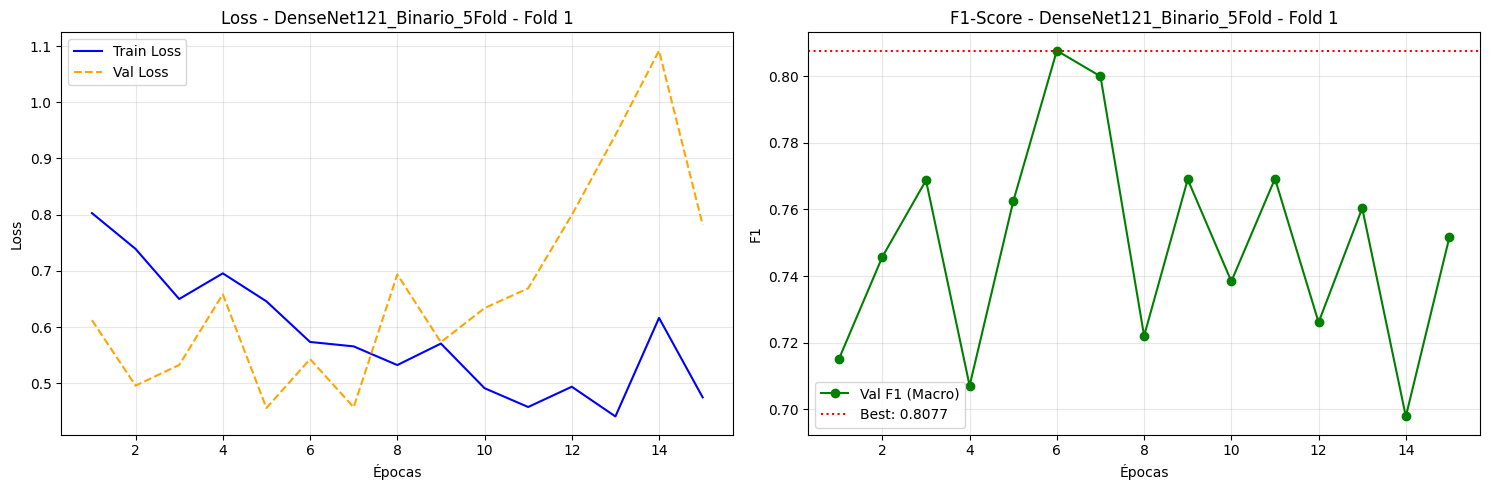

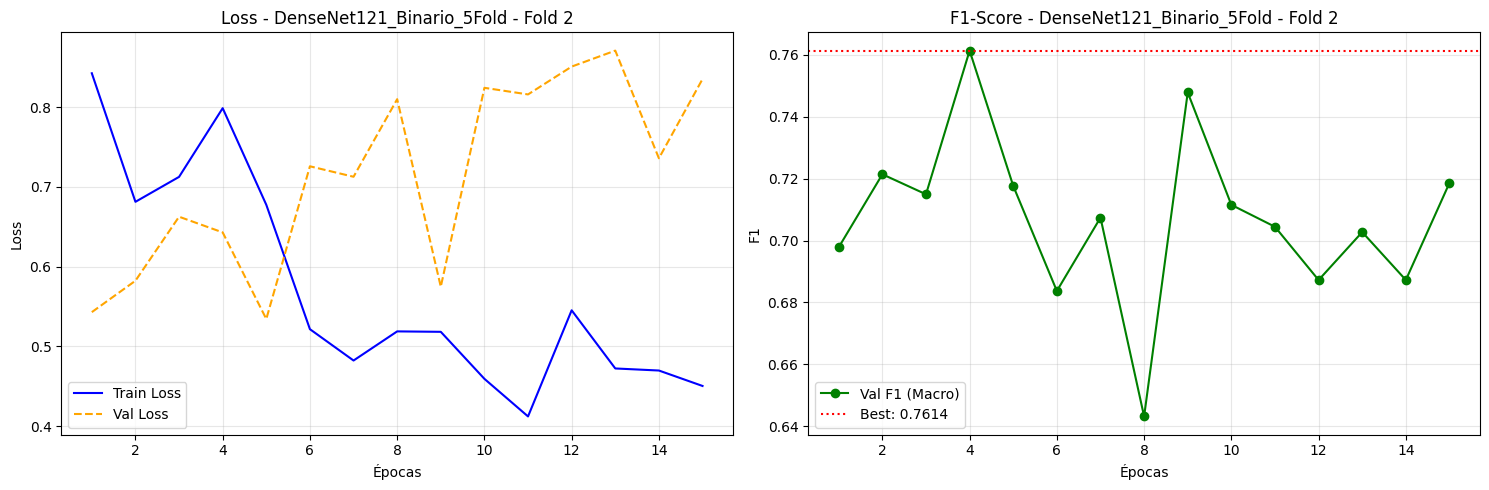

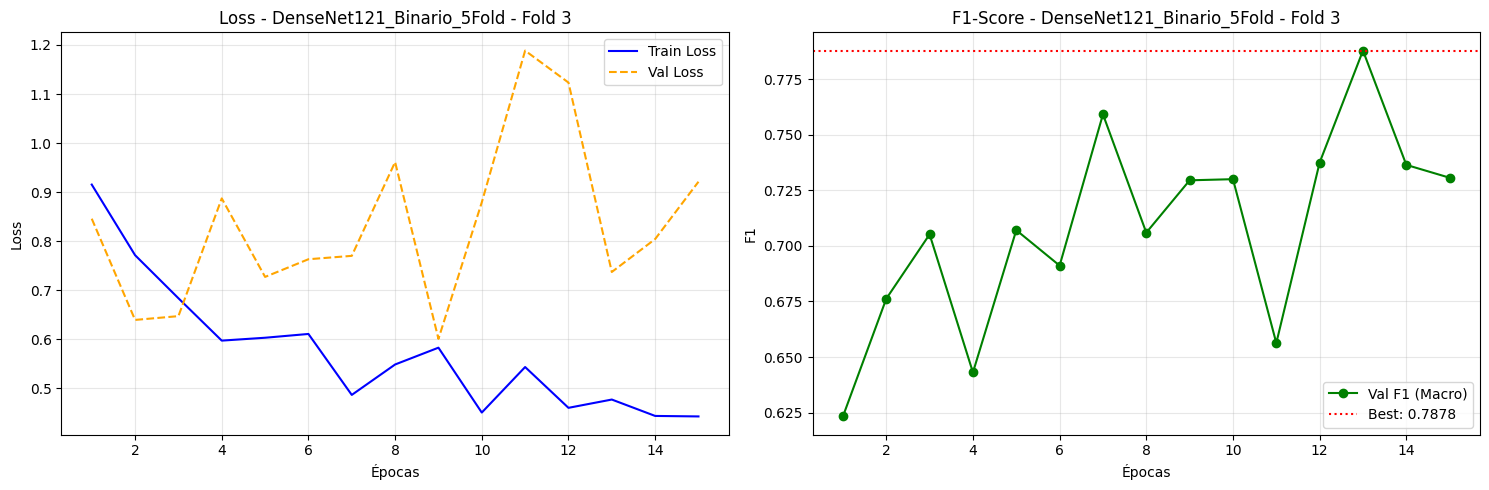

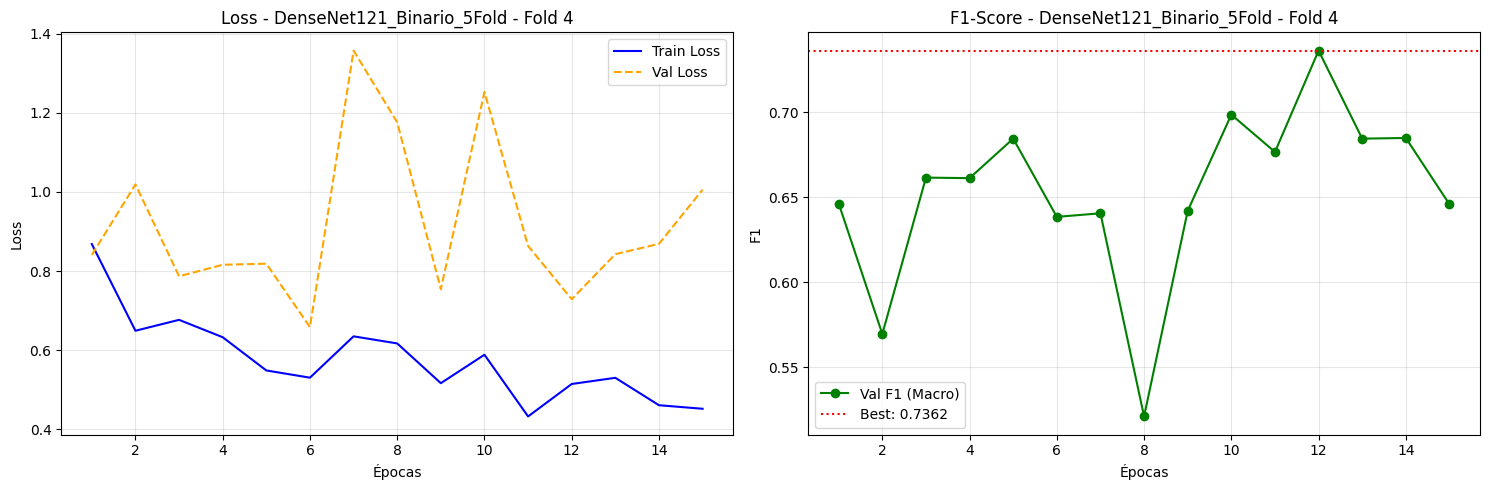

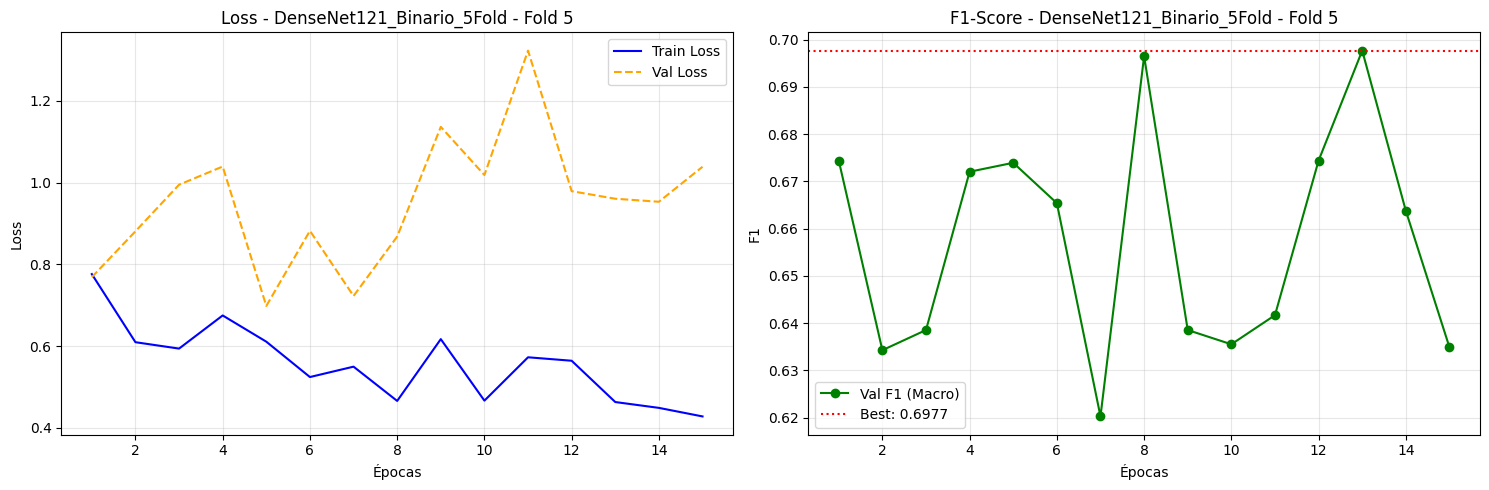


 MATRICES DE CONFUSIÓN POR FOLD (VALIDACIÓN) - DenseNet121_Binario_5Fold


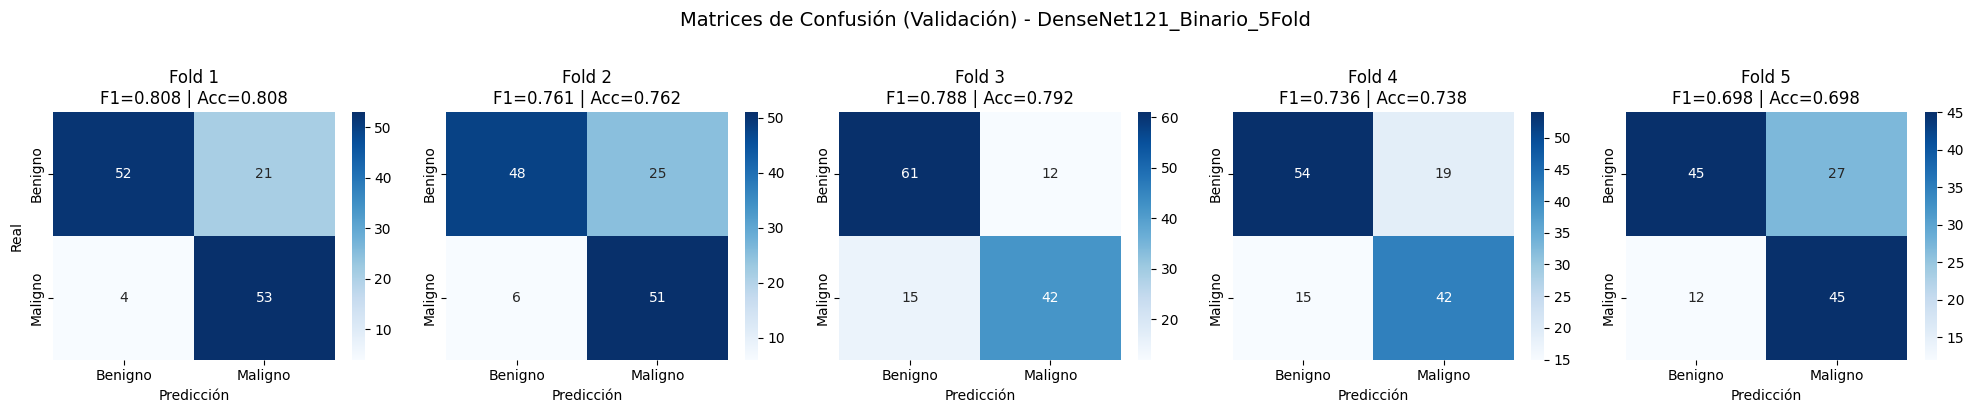


 EVALUACIÓN GLOBAL VALIDACIÓN (todos los folds) - DenseNet121_Binario_5Fold


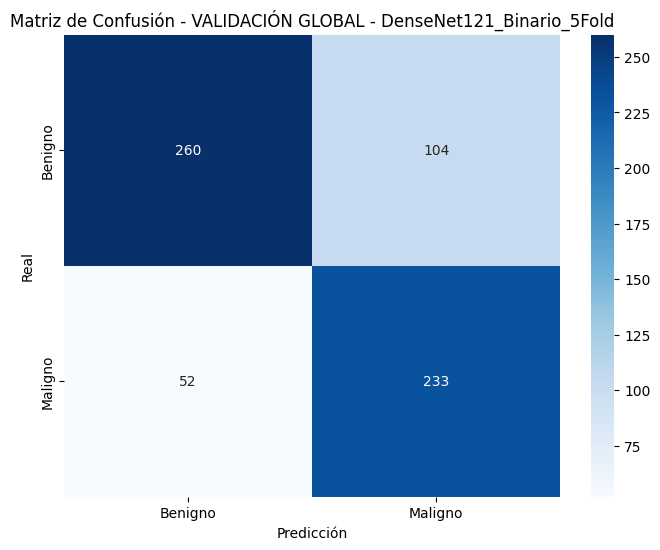


REPORTE: VALIDACIÓN GLOBAL - DenseNet121_Binario_5Fold
              precision    recall  f1-score   support

     Benigno       0.83      0.71      0.77       364
     Maligno       0.69      0.82      0.75       285

    accuracy                           0.76       649
   macro avg       0.76      0.77      0.76       649
weighted avg       0.77      0.76      0.76       649

────────────────────────────────────────────────────────────
  Accuracy:           0.7596
  F1 Macro:           0.7592
  Recall Macro:       0.7659
  Cohen's Kappa:      0.5215

MEJOR FOLD: 1 (F1 Macro Val = 0.8077)


In [7]:
import torchvision.models as models
import torch.optim as optim
import torch.nn as nn

# --- Definición de la factoría para DenseNet ---
def crear_densenet121(num_classes, device):
    # 1. Cargar pesos pre-entrenados
    weights = models.DenseNet121_Weights.DEFAULT
    model = models.densenet121(weights=weights)

    # 2. Congelar todo el backbone inicialmente
    for param in model.features.parameters():
        param.requires_grad = False

    # 3. Descongelar últimos bloques (Fine-tuning profundo)
    for param in model.features.denseblock4.parameters():
        param.requires_grad = True
        
    for param in model.features.norm5.parameters():
        param.requires_grad = True

    # 4. Nueva cabeza de clasificación binaria
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, num_classes)
    )

    model = model.to(device)

    # 5. Optimizador con Learning Rates diferenciales
    # Capas profundas (features) -> LR bajo (1e-4)
    # Clasificador (cabeza nueva) -> LR alto (1e-3)
    optimizer = optim.AdamW([
        {'params': model.features.denseblock4.parameters(), 'lr': 0.000811},
        {'params': model.features.norm5.parameters(), 'lr': 0.000811},
        {'params': model.classifier.parameters(), 'lr': 0.003550}
    ], weight_decay=0.057279)
    
    return model, optimizer

# --- Lanzar el Experimento 5-Fold ---
# IMPORTANTE: batch_size=16 para DenseNet
resultados_densenet = lanzar_experimento_kfold(
    crear_modelo_fn=crear_densenet121,
    nombre_exp="DenseNet121_Binario_5Fold",
    device=device,
    batch_size=16,  # <--- Batch reducido
    epochs=15
)

### Resultados del 5-Fold CV

#### Métricas de Validación

| Métrica | Media | Std | Rango |
|---------|-------|-----|-------|
| **F1-Macro** | **0.7582** | 0.0387 | 0.6977 - 0.8077 |
| Accuracy | 0.7595 | 0.0392 | 0.6977 - 0.8077 |
| Recall-Macro | 0.7658 | 0.0394 | 0.7072 - 0.8211 |
| Cohen's Kappa | 0.5214 | 0.0767 | 0.4034 - 0.6218 |

**Mejor Fold:** #1 (F1=0.8077) | **Peor Fold:** #5 (F1=0.6977)

#### Rendimiento por Clase

|  | Precision | Recall | F1-Score |
|--|-----------|--------|----------|
| **Benigno** | 0.83 | 0.71 | 0.77 |
| **Maligno** | 0.69 | **0.82** | 0.75 |

DenseNet pierde 52 malignos (18% FN), 5 más que ResNet.

#### Comparación con ResNet

| Modelo | F1-Macro | Recall Maligno | FN |
|--------|----------|----------------|-----|
| **ResNet18** | **0.7667** | **0.84** | 47 |
| DenseNet121 | 0.7582 | 0.82 | 52 |

DenseNet queda ligeramente por debajo de ResNet en todas las métricas importantes. A pesar de ser más complejo, no aporta mejora. Probablemente el dataset es demasiado pequeño (649 imgs) para aprovechar su mayor capacidad.

## 7. Entrenamiento: YOLO26x

### Arquitectura

YOLO está diseñado originalmente para detección de objetos, no clasificación. Usamos su variante de clasificación (yolo26x-cls) para ver cómo se comporta en nuestro problema.

**Transfer learning:**
- Modelo base: yolo26x-cls.pt (preentrenado en ImageNet)
- Fine-tuning completo (sin congelar capas)

### Hiperparámetros (Trial #11 de Optuna)

| Parámetro | Valor |
|-----------|-------|
| lr0 | 0.000819 |
| lrf | 0.061386 |
| momentum | 0.860263 |
| optimizer | Adam |
| weight_decay | 0.000097 |
| dropout | 0.5 |

YOLO usa weight decay muy bajo comparado con los otros modelos, y optimizador Adam en vez de AdamW.


 EXPERIMENTO 5-FOLD YOLO: YOLO26x_CV
Directorio de folds detectado: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_BINARIO/folds_5cv

 FOLD 1/5 (Datos: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_BINARIO/folds_5cv/fold_1)
New https://pypi.org/project/ultralytics/8.4.9 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.7 🚀 Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_BINARIO/folds_5cv/fold_1, degrees=0.0, deterministic=True

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 644.9±463.3 MB/s, size: 1787.2 KB)
train: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_BINARIO/folds_5cv/fold_1/train... 519 images, 0 corrupt: 100% ━━━━━━━━━━━━ 519/519 128.0Mit/s 0.0s
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 188.2±131.2 MB/s, size: 691.0 KB)
val: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_BINARIO/folds_5cv/fold_1/val... 130 images, 0 corrupt: 100% ━━━━━━━━━━━━ 130/130 4.0Mit/s 0.0s
optimizer: Adam(lr=0.000819, momentum=0.860263) with parameter groups 82 weight(decay=0.0), 83 weight(decay=9.7e-05), 83 bias(decay=0.0)
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/final_binario/runs/classify/runs/YOLO26x_CV/fold_1
Starting tr

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

       1/15      1.79G     0.8178         16        224: 0% ──────────── 0/33  4.4s

...

       4/15      2.34G     0.5678          8        224: 100% ━━━━━━━━━━━━ 33/33 10.4it/s 3.2s0.1s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 28.4it/s 0.2s.2s
                   all      0.667          1

      Epoch    GPU_mem       loss  Instances       Size
       5/15      2.34G     0.6377         16        224: 3% ──────────── 1/33 1.8it/s 0.2s<17.3s

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

       5/15      2.36G     0.5813          8        224: 100% ━━━━━━━━━━━━ 33/33 10.4it/s 3.2s0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 28.2it/s 0.2s.2s
                   all      0.667          1

      Epoch    GPU_mem       loss  Instances       Size
       6/15       2.4G     0.4807         16        224: 0% ──────────── 0/33  0.5s

/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1324: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/ultralytics/nn/modules/block.py:1326: UserWarning: Deterministic behavior was enabled with either `to

       6/15      2.42G     0.5063          8        224: 100% ━━━━━━━━━━━━ 33/33 7.5it/s 4.4s0.3ss
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 5/5 28.5it/s 0.2s.2s
                   all      0.682          1
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 1, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

6 epochs completed in 0.009 hours.
Optimizer stripped from /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/final_binario/runs/classify/runs/YOLO26x_CV/fold_5/weights/last.pt, 57.0MB
Optimizer stripped from /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/DAVID/final_binario/runs/classify/runs/YOLO26x_CV/fold_5/weights/best.pt, 57.0MB

Validating /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNIN

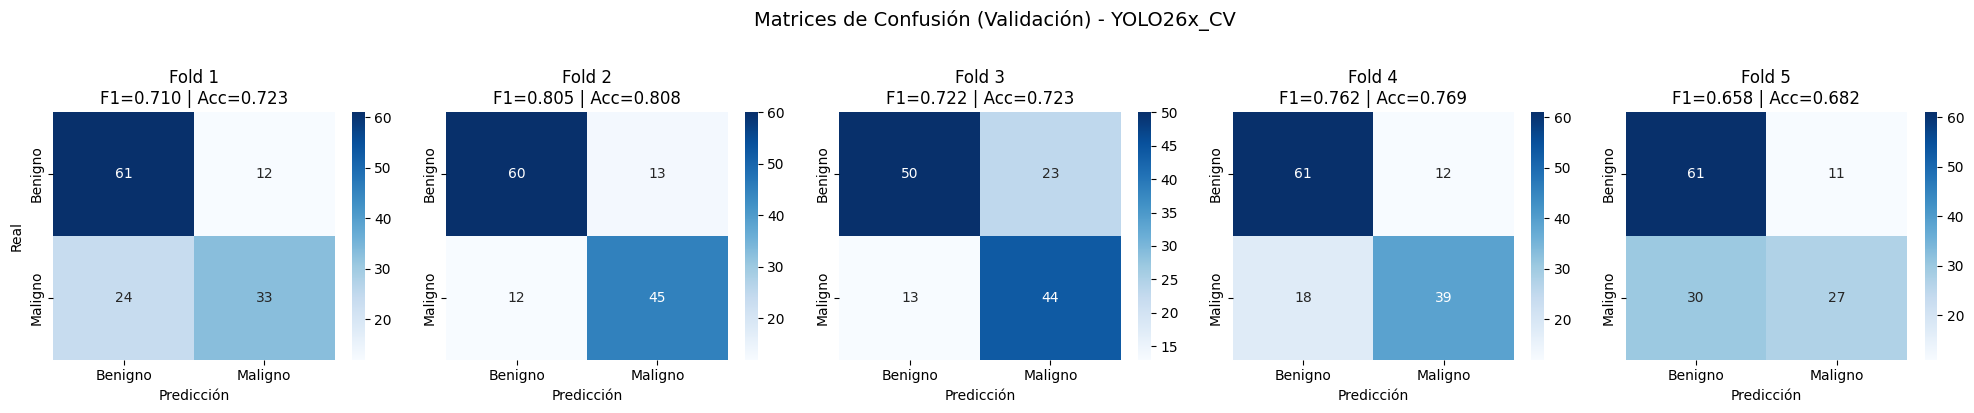


 EVALUACIÓN GLOBAL VALIDACIÓN - YOLO26x_CV


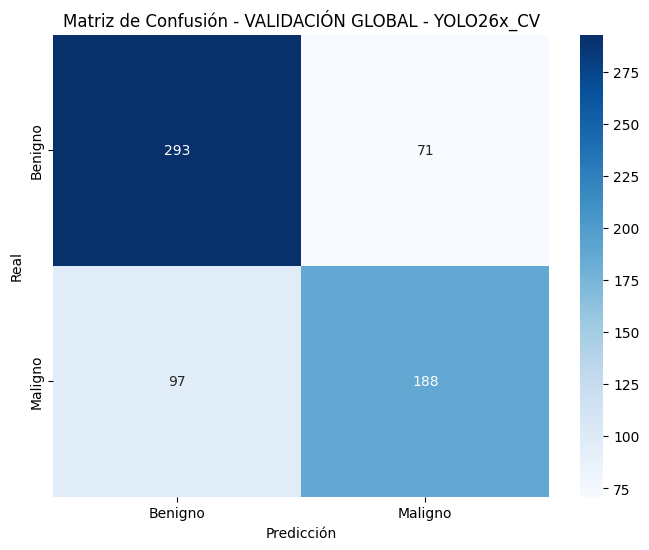


REPORTE: VALIDACIÓN GLOBAL - YOLO26x_CV
              precision    recall  f1-score   support

     Benigno       0.75      0.80      0.78       364
     Maligno       0.73      0.66      0.69       285

    accuracy                           0.74       649
   macro avg       0.74      0.73      0.73       649
weighted avg       0.74      0.74      0.74       649

────────────────────────────────────────────────────────────
  Accuracy:           0.7411
  F1 Macro:           0.7342
  Recall Macro:       0.7323
  Cohen's Kappa:      0.4692

MEJOR FOLD YOLO: 2 (F1 Macro Val = 0.8051)


In [8]:
import os
import shutil
import gc
import torch
from ultralytics import YOLO

# --- Configuración y Params Optimizados ---
PARAMS_YOLO = {
    'dropout': 0.5,
    'lr0': 0.000819,
    'lrf': 0.061386,
    'momentum': 0.860263,
    'optimizer': 'Adam',
    'weight_decay': 0.000097,
    'imgsz': 224,
    'batch': 16,
    'patience': 5
}

# --- Asegurar Folds Físicos (Necesario para YOLO) ---
FOLDS_DIR = os.path.abspath(f"{RUTA_BASE}/folds_5cv")

def preparar_folds_yolo():
    """Si no existen, crea la estructura física folds_5cv"""
    if os.path.exists(FOLDS_DIR):
        print(f"Directorio de folds detectado: {FOLDS_DIR}")
        return

    print(f"Creando directorios físicos en {FOLDS_DIR}...")
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(range(len(targets)), targets)):
        fold_name = f"fold_{fold_idx+1}"

        # Train
        for i in train_idx:
            src = full_train_dataset.samples[i][0]
            cls = full_train_dataset.classes[targets[i]]
            dst = os.path.join(FOLDS_DIR, fold_name, "train", cls, os.path.basename(src))
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            if not os.path.exists(dst): shutil.copy2(src, dst)

        # Val
        for i in val_idx:
            src = full_train_dataset.samples[i][0]
            cls = full_train_dataset.classes[targets[i]]
            dst = os.path.join(FOLDS_DIR, fold_name, "val", cls, os.path.basename(src))
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            if not os.path.exists(dst): shutil.copy2(src, dst)

# --- Funciones de Inferencia Adaptadas a YOLO ---
def predecir_yolo(model, dataset_path, classes):
    y_true, y_pred, y_probs = [], [], []
    for class_idx, class_name in enumerate(classes):
        class_dir = os.path.join(dataset_path, class_name)
        if not os.path.exists(class_dir): continue
        for img_file in os.listdir(class_dir):
            if not img_file.lower().endswith(('.png', '.jpg', '.jpeg')): continue
            img_path = os.path.join(class_dir, img_file)

            results = model(img_path, verbose=False)
            res = results[0]
            probs = res.probs.data.cpu().numpy()
            pred = res.probs.top1

            y_true.append(class_idx)
            y_pred.append(pred)
            y_probs.append(probs)
    return np.array(y_true), np.array(y_pred), np.array(y_probs)

# --- BUCLE PRINCIPAL YOLO CV (SIN TEST) ---
def lanzar_yolo_cv(nombre_exp="YOLO26x_CV", epochs=15):
    print(f"\n{'='*70}\n EXPERIMENTO 5-FOLD YOLO: {nombre_exp}\n{'='*70}")

    preparar_folds_yolo()
    classes = full_train_dataset.classes
    num_classes = len(classes)
    metricas_folds = []
    trained_models = []
    predicciones_val_por_fold = []

    # Acumular predicciones de validación
    y_true_val_todos = []
    y_pred_val_todos = []
    y_probs_val_todos = []

    for fold_idx in range(K_FOLDS):
        fold_path = os.path.join(FOLDS_DIR, f"fold_{fold_idx+1}")
        print(f"\n FOLD {fold_idx+1}/{K_FOLDS} (Datos: {fold_path})")

        # 1. Cargar Modelo
        model = YOLO('yolo26x-cls.pt')

        # 2. Entrenar
        model.train(
            data=fold_path,
            epochs=epochs,
            project=f"runs/{nombre_exp}",
            name=f"fold_{fold_idx+1}",
            exist_ok=True,
            plots=False,
            **PARAMS_YOLO
        )

        # 3. Validar
        print("   Evaluando métricas en Val...")
        val_path = os.path.join(fold_path, "val")
        yt, yp, yprobs = predecir_yolo(model, val_path, classes)

        mets = calcular_metricas(yt, yp)
        print(f"   Fin Fold {fold_idx+1}: F1(Macro)={mets['f1_macro']:.4f} | Acc={mets['accuracy']:.4f}")
        metricas_folds.append(mets)
        predicciones_val_por_fold.append((yt, yp))

        # Acumular
        y_true_val_todos.extend(yt)
        y_pred_val_todos.extend(yp)
        y_probs_val_todos.extend(yprobs)

        # Ruta correcta del best.pt
        best_pt = f"runs/classify/runs/{nombre_exp}/fold_{fold_idx+1}/weights/best.pt"
        trained_models.append(best_pt)

        # --- LIMPIEZA DE MEMORIA ---
        del model
        gc.collect()
        torch.cuda.empty_cache()
        print(f"   Memoria liberada.")

    # --- RESUMEN CV ---
    print(f"\n{'='*70}\n RESUMEN VALIDACIÓN (CV) - {nombre_exp}\n{'='*70}")
    df = pd.DataFrame(metricas_folds, index=[f"Fold {i+1}" for i in range(K_FOLDS)])
    df.loc['Media'] = df.mean()
    df.loc['Std'] = df.std()
    print(df[['f1_macro', 'accuracy', 'recall_macro', 'kappa']].round(4).to_string())

    # --- MATRICES DE CONFUSIÓN POR FOLD (VALIDACIÓN) ---
    print(f"\n{'='*70}\n MATRICES DE CONFUSIÓN POR FOLD (VALIDACIÓN) - {nombre_exp}\n{'='*70}")
    mostrar_matrices_confusion_folds(predicciones_val_por_fold, classes, nombre_exp)

    # --- EVALUACIÓN GLOBAL EN VALIDACIÓN ---
    print(f"\n{'='*70}\n EVALUACIÓN GLOBAL VALIDACIÓN - {nombre_exp}\n{'='*70}")

    y_true_val_todos = np.array(y_true_val_todos)
    y_pred_val_todos = np.array(y_pred_val_todos)

    metricas_val_global = mostrar_reporte_completo(
        y_true_val_todos, y_pred_val_todos, classes,
        f"VALIDACIÓN GLOBAL - {nombre_exp}"
    )

    # --- MEJOR FOLD ---
    f1_scores = [m['f1_macro'] for m in metricas_folds]
    best_fold = int(np.argmax(f1_scores))

    print(f"\n{'='*70}")
    print(f"MEJOR FOLD YOLO: {best_fold+1} (F1 Macro Val = {f1_scores[best_fold]:.4f})")
    print(f"{'='*70}")

    return {
        'df_resumen': df,
        'metricas_folds': metricas_folds,
        'trained_models': trained_models,
        'predicciones_val_por_fold': predicciones_val_por_fold,
        'metricas_val_global': metricas_val_global,
        'best_fold': best_fold,
        'classes': classes,
    }

# --- EJECUTAR ---
resultados_yolo = lanzar_yolo_cv(epochs=15)


### Resultados del 5-Fold CV

#### Métricas de Validación

| Métrica | Media | Std | Rango |
|---------|-------|-----|-------|
| **F1-Macro** | **0.7316** | 0.0495 | 0.6584 - 0.8051 |
| Accuracy | 0.7410 | 0.0432 | 0.6822 - 0.8077 |
| Recall-Macro | 0.7324 | 0.0489 | 0.6605 - 0.8057 |
| Cohen's Kappa | 0.4682 | 0.0941 | 0.3324 - 0.6102 |

**Mejor Fold:** #2 (F1=0.8051) | **Peor Fold:** #5 (F1=0.6584)

#### Rendimiento por Clase

|  | Precision | Recall | F1-Score |
|--|-----------|--------|----------|
| **Benigno** | 0.80 | 0.75 | 0.77 |
| **Maligno** | 0.73 | **0.66** | 0.69 |

YOLO pierde **97 malignos de 285** (34% de FN). Esto es mucho peor que ResNet (16%) y DenseNet (18%).

#### Comparación de los 3 Modelos

| Modelo | F1-Macro | Recall Maligno | FN |
|--------|----------|----------------|-----|
| **ResNet18** | **0.7667** | **0.84** | 47 |
| DenseNet121 | 0.7582 | 0.82 | 52 |
| YOLO26x | 0.7316 | 0.66 | 97 |

#### Análisis

El resultado de YOLO es bastante malo para nuestro propósito:
- **Recall de maligno muy bajo (66%)**: pierde 1 de cada 3 malignos
- **Alta variabilidad entre folds**: el Fold #5 colapsa a 0.66
- **Doble de FN que ResNet**: 97 vs 47

Esto tiene sentido: YOLO está optimizado para detección, no clasificación pura. Su arquitectura no es la ideal para este problema.

A pesar de estos resultados, incluiremos YOLO en el ensemble para ver si aporta diversidad, aunque con expectativas bajas.

## 8. Selección del Mejor Fold por Modelo

### Metodología

Para el ensemble final, seleccionamos el mejor fold de cada modelo usando **AUC ROC** como criterio (mide la capacidad discriminativa del modelo independientemente del umbral de decisión).

Para cada modelo:
1. Cargamos los 5 checkpoints
2. Evaluamos AUC ROC en su validación correspondiente
3. Seleccionamos el fold con mayor AUC

COMPARATIVA AUC ROC - 5 FOLDS (VALIDACIÓN)

>>> Evaluando ResNet 5 folds en validación...
>>> Evaluando DenseNet 5 folds en validación...
>>> Evaluando YOLO 5 folds en validación...


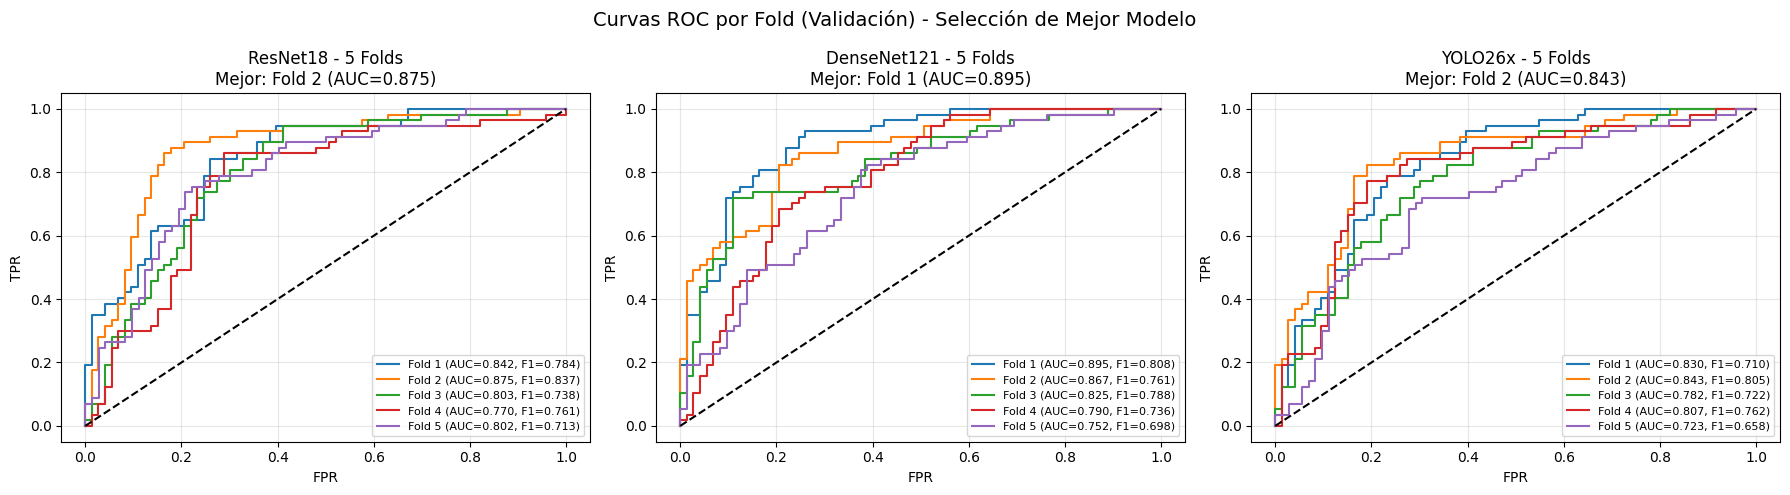


RESUMEN: MEJORES FOLDS POR MODELO
     Modelo  Mejor_Fold  Mejor_AUC  Mejor_F1
   ResNet18           2     0.8750    0.8368
DenseNet121           1     0.8950    0.8077
    YOLO26x           2     0.8428    0.8051

>>> Mejores folds guardados:
    MEJOR_FOLD_RESNET = 2
    MEJOR_FOLD_DENSENET = 1
    MEJOR_FOLD_YOLO = 2


In [11]:
# ============================================================
# COMPARATIVA AUC ROC DE LOS 5 FOLDS - SELECCIÓN DE MEJOR FOLD
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, f1_score
import torch
from ultralytics import YOLO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = full_train_dataset.classes
num_classes = len(classes)
pos_idx = 1  # Clase positiva (Maligno)

print("="*70)
print("COMPARATIVA AUC ROC - 5 FOLDS (VALIDACIÓN)")
print("="*70)

# ============================================================
# 1. RESNET - AUC ROC de los 5 folds
# ============================================================

print("\n>>> Evaluando ResNet 5 folds en validación...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ResNet
ax = axes[0]
resnet_aucs = []
resnet_f1s = []

for fold_idx in range(K_FOLDS):
    # Cargar modelo
    model, _ = crear_resnet18(num_classes, device)
    model.load_state_dict(torch.load(f"ResNet18_Binario_5Fold_fold{fold_idx+1}.pth", map_location=device))
    model.eval()
    
    # Obtener val loader del fold
    _, val_loader = get_fold_loaders(fold_idx, 32)
    
    # Predicciones
    y_true, y_pred, y_probs = obtener_predicciones(model, val_loader, device)
    
    # AUC ROC
    fpr, tpr, _ = roc_curve(y_true, y_probs[:, pos_idx])
    roc_auc = auc(fpr, tpr)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    resnet_aucs.append(roc_auc)
    resnet_f1s.append(f1)
    
    ax.plot(fpr, tpr, label=f'Fold {fold_idx+1} (AUC={roc_auc:.3f}, F1={f1:.3f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'ResNet18 - 5 Folds\nMejor: Fold {np.argmax(resnet_aucs)+1} (AUC={max(resnet_aucs):.3f})')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# ============================================================
# 2. DENSENET - AUC ROC de los 5 folds
# ============================================================

print(">>> Evaluando DenseNet 5 folds en validación...")

ax = axes[1]
densenet_aucs = []
densenet_f1s = []

for fold_idx in range(K_FOLDS):
    model, _ = crear_densenet121(num_classes, device)
    model.load_state_dict(torch.load(f"DenseNet121_Binario_5Fold_fold{fold_idx+1}.pth", map_location=device))
    model.eval()
    
    _, val_loader = get_fold_loaders(fold_idx, 16)
    y_true, y_pred, y_probs = obtener_predicciones(model, val_loader, device)
    
    fpr, tpr, _ = roc_curve(y_true, y_probs[:, pos_idx])
    roc_auc = auc(fpr, tpr)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    densenet_aucs.append(roc_auc)
    densenet_f1s.append(f1)
    
    ax.plot(fpr, tpr, label=f'Fold {fold_idx+1} (AUC={roc_auc:.3f}, F1={f1:.3f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'DenseNet121 - 5 Folds\nMejor: Fold {np.argmax(densenet_aucs)+1} (AUC={max(densenet_aucs):.3f})')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# ============================================================
# 3. YOLO - AUC ROC de los 5 folds
# ============================================================

print(">>> Evaluando YOLO 5 folds en validación...")

ax = axes[2]
yolo_aucs = []
yolo_f1s = []

for fold_idx in range(K_FOLDS):
    model_yolo = YOLO(f"runs/classify/runs/YOLO26x_CV/fold_{fold_idx+1}/weights/best.pt")
    
    # Carpeta de validación del fold
    val_path = os.path.join(FOLDS_DIR, f"fold_{fold_idx+1}", "val")
    y_true, y_pred, y_probs = predecir_yolo(model_yolo, val_path, classes)
    
    fpr, tpr, _ = roc_curve(y_true, y_probs[:, pos_idx])
    roc_auc = auc(fpr, tpr)
    f1 = f1_score(y_true, y_pred, average='macro')
    
    yolo_aucs.append(roc_auc)
    yolo_f1s.append(f1)
    
    ax.plot(fpr, tpr, label=f'Fold {fold_idx+1} (AUC={roc_auc:.3f}, F1={f1:.3f})')
    
    del model_yolo
    gc.collect()
    torch.cuda.empty_cache()

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'YOLO26x - 5 Folds\nMejor: Fold {np.argmax(yolo_aucs)+1} (AUC={max(yolo_aucs):.3f})')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Curvas ROC por Fold (Validación) - Selección de Mejor Modelo', fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# TABLA RESUMEN
# ============================================================

import pandas as pd

print("\n" + "="*70)
print("RESUMEN: MEJORES FOLDS POR MODELO")
print("="*70)

resumen = pd.DataFrame({
    'Modelo': ['ResNet18', 'DenseNet121', 'YOLO26x'],
    'Mejor_Fold': [np.argmax(resnet_aucs)+1, np.argmax(densenet_aucs)+1, np.argmax(yolo_aucs)+1],
    'Mejor_AUC': [max(resnet_aucs), max(densenet_aucs), max(yolo_aucs)],
    'Mejor_F1': [resnet_f1s[np.argmax(resnet_aucs)], densenet_f1s[np.argmax(densenet_aucs)], yolo_f1s[np.argmax(yolo_aucs)]]
})
print(resumen.round(4).to_string(index=False))

# Guardar mejores folds
MEJOR_FOLD_RESNET = np.argmax(resnet_aucs) + 1
MEJOR_FOLD_DENSENET = np.argmax(densenet_aucs) + 1
MEJOR_FOLD_YOLO = np.argmax(yolo_aucs) + 1

print(f"\n>>> Mejores folds guardados:")
print(f"    MEJOR_FOLD_RESNET = {MEJOR_FOLD_RESNET}")
print(f"    MEJOR_FOLD_DENSENET = {MEJOR_FOLD_DENSENET}")
print(f"    MEJOR_FOLD_YOLO = {MEJOR_FOLD_YOLO}")


### Resultados de la Selección

#### Mejores Folds

| Modelo | Mejor Fold | AUC ROC | F1-Macro |
|--------|------------|---------|----------|
| **DenseNet121** | Fold 1 | **0.8950** | 0.8077 |
| **ResNet18** | Fold 2 | 0.8750 | **0.8368** |
| **YOLO26x** | Fold 2 | 0.8428 | 0.8051 |

Es interesante que DenseNet tenga el mejor AUC pero ResNet el mejor F1. Esto sugiere que DenseNet discrimina bien las probabilidades pero su punto de corte óptimo no está exactamente en 0.5.

Los tres modelos tienen arquitecturas diferentes (residual, dense, detection-based), lo cual es bueno para el ensemble ya que aportan perspectivas complementarias.

## 9. Evaluación del Ensemble en Test

### Metodología

Combinamos los 3 mejores modelos usando **soft voting**: promediamos las probabilidades predichas y tomamos la clase con mayor probabilidad media.

```python
P_ensemble = 0.33 × P_ResNet + 0.33 × P_DenseNet + 0.34 × P_YOLO
```

Soft voting aprovecha la confianza de cada modelo, a diferencia del hard voting que solo cuenta votos.

Cargando mejores modelos:
  ResNet: Fold 2
  DenseNet: Fold 1
  YOLO: Fold 2
✓ Modelos cargados
✓ Predicciones obtenidas: 153 muestras en test

RESULTADOS EN TEST (BINARIO)
ResNet Fold2:     F1 = 0.7819
DenseNet Fold1:   F1 = 0.7124
YOLO Fold2:       F1 = 0.7253
──────────────────────────────────────────────────
Ensemble (0.33/0.33/0.34): F1 = 0.7837


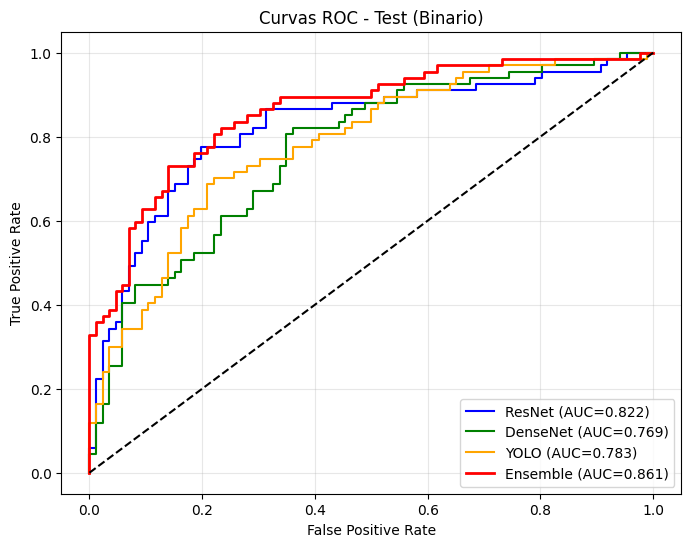

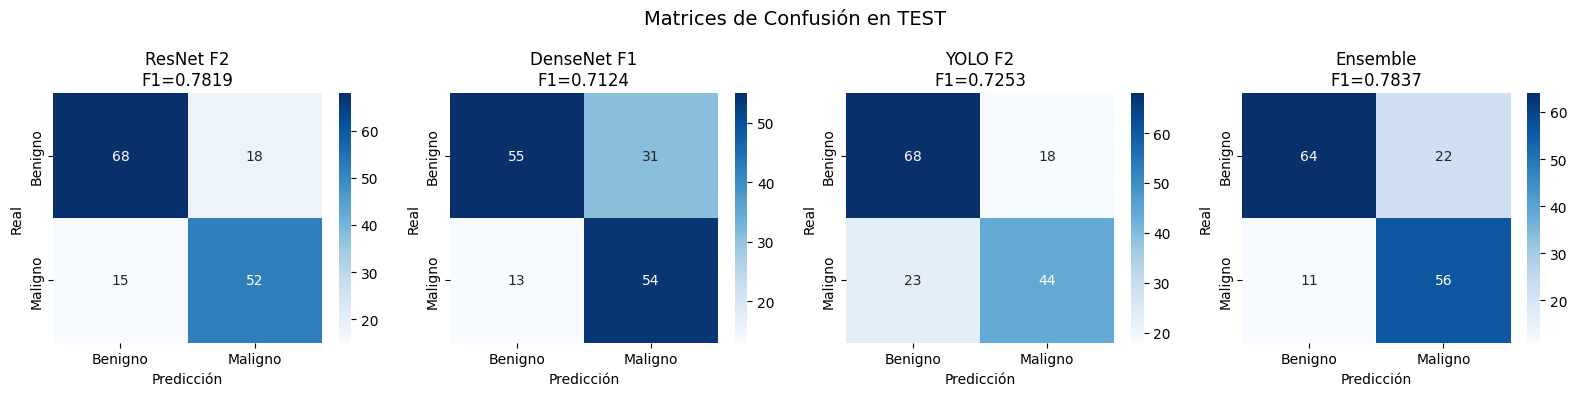

In [ ]:
# ============================================================
# ENSEMBLE MANUAL - EVALUACIÓN EN TEST (BINARIO)
# ============================================================

import numpy as np
import torch
from ultralytics import YOLO
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = full_train_dataset.classes
num_classes = len(classes)
pos_idx = 1  # Clase positiva

# ============================================================
# 1. CARGAR LOS 3 MEJORES MODELOS
# ============================================================

# --- USA LOS MEJORES FOLDS DE LA CELDA ANTERIOR ---
# (o ajústalos manualmente si prefieres)
BEST_FOLD_RESNET = MEJOR_FOLD_RESNET
BEST_FOLD_DENSENET = MEJOR_FOLD_DENSENET
BEST_FOLD_YOLO = MEJOR_FOLD_YOLO

print(f"Cargando mejores modelos:")
print(f"  ResNet: Fold {BEST_FOLD_RESNET}")
print(f"  DenseNet: Fold {BEST_FOLD_DENSENET}")
print(f"  YOLO: Fold {BEST_FOLD_YOLO}")

# ResNet
model_resnet, _ = crear_resnet18(num_classes, device)
model_resnet.load_state_dict(torch.load(f"ResNet18_Binario_5Fold_fold{BEST_FOLD_RESNET}.pth", map_location=device))
model_resnet.eval()

# DenseNet
model_densenet, _ = crear_densenet121(num_classes, device)
model_densenet.load_state_dict(torch.load(f"DenseNet121_Binario_5Fold_fold{BEST_FOLD_DENSENET}.pth", map_location=device))
model_densenet.eval()

# YOLO
model_yolo = YOLO(f"runs/classify/runs/YOLO26x_CV/fold_{BEST_FOLD_YOLO}/weights/best.pt")

print("✓ Modelos cargados")

# ============================================================
# 2. OBTENER PREDICCIONES EN TEST
# ============================================================

test_loader_res = get_test_loader(32)
test_loader_dens = get_test_loader(16)

# ResNet
y_true_test, _, probs_resnet = obtener_predicciones(model_resnet, test_loader_res, device)

# DenseNet
_, _, probs_densenet = obtener_predicciones(model_densenet, test_loader_dens, device)

# YOLO
RUTA_TEST = f"{RUTA_BASE}/test"
_, _, probs_yolo = predecir_yolo(model_yolo, RUTA_TEST, classes)

print(f"✓ Predicciones obtenidas: {len(y_true_test)} muestras en test")

# Convertir probs a predicciones
y_pred_resnet = np.argmax(probs_resnet, axis=1)
y_pred_densenet = np.argmax(probs_densenet, axis=1)
y_pred_yolo = np.argmax(probs_yolo, axis=1)

# ============================================================
# 3. ENSEMBLE CON PESOS MANUALES
# ============================================================

# --- AJUSTA ESTOS PESOS ---
w_resnet = 0.34
w_densenet = 0.33
w_yolo = 0.33
# --------------------------

probs_ensemble = w_resnet * probs_resnet + w_densenet * probs_densenet + w_yolo * probs_yolo
preds_ensemble = np.argmax(probs_ensemble, axis=1)

# ============================================================
# 4. MÉTRICAS
# ============================================================

f1_r = f1_score(y_true_test, y_pred_resnet, average='macro')
f1_d = f1_score(y_true_test, y_pred_densenet, average='macro')
f1_y = f1_score(y_true_test, y_pred_yolo, average='macro')
f1_e = f1_score(y_true_test, preds_ensemble, average='macro')

print(f"\n{'='*50}")
print(f"RESULTADOS EN TEST (BINARIO)")
print(f"{'='*50}")
print(f"ResNet Fold{BEST_FOLD_RESNET}:     F1 = {f1_r:.4f}")
print(f"DenseNet Fold{BEST_FOLD_DENSENET}:   F1 = {f1_d:.4f}")
print(f"YOLO Fold{BEST_FOLD_YOLO}:       F1 = {f1_y:.4f}")
print(f"{'─'*50}")
print(f"Ensemble ({w_resnet}/{w_densenet}/{w_yolo}): F1 = {f1_e:.4f}")
print(f"{'='*50}")

# ============================================================
# 5. CURVAS ROC
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

fpr_r, tpr_r, _ = roc_curve(y_true_test, probs_resnet[:, pos_idx])
auc_r = auc(fpr_r, tpr_r)
ax.plot(fpr_r, tpr_r, label=f'ResNet (AUC={auc_r:.3f})', color='blue')

fpr_d, tpr_d, _ = roc_curve(y_true_test, probs_densenet[:, pos_idx])
auc_d = auc(fpr_d, tpr_d)
ax.plot(fpr_d, tpr_d, label=f'DenseNet (AUC={auc_d:.3f})', color='green')

fpr_y, tpr_y, _ = roc_curve(y_true_test, probs_yolo[:, pos_idx])
auc_y = auc(fpr_y, tpr_y)
ax.plot(fpr_y, tpr_y, label=f'YOLO (AUC={auc_y:.3f})', color='orange')

fpr_e, tpr_e, _ = roc_curve(y_true_test, probs_ensemble[:, pos_idx])
auc_e = auc(fpr_e, tpr_e)
ax.plot(fpr_e, tpr_e, label=f'Ensemble (AUC={auc_e:.3f})', color='red', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC - Test (Binario)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.show()

# ============================================================
# 6. MATRICES DE CONFUSIÓN
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (name, y_pred, f1) in zip(axes, [
    (f'ResNet F{BEST_FOLD_RESNET}', y_pred_resnet, f1_r),
    (f'DenseNet F{BEST_FOLD_DENSENET}', y_pred_densenet, f1_d),
    (f'YOLO F{BEST_FOLD_YOLO}', y_pred_yolo, f1_y),
    ('Ensemble', preds_ensemble, f1_e)
]):
    cm = confusion_matrix(y_true_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f'{name}\nF1={f1:.4f}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

plt.suptitle('Matrices de Confusión en TEST', fontsize=14)
plt.tight_layout()
plt.show()


### Resultados en Test

| Modelo | F1-Macro | AUC ROC | FN (Malignos no detectados) | FP (Falsos positivos) |
|--------|----------|---------|-----------------------------|-----------------------|
| ResNet Fold 2 | 0.7819 | 0.8223 | 15 | 18 |
| DenseNet Fold 1 | 0.7124 | 0.7690 | 13 | 31 |
| YOLO Fold 2 | 0.6700 | 0.7721 | 23 | 27 |
| **Ensemble** | **0.7901** | **0.8598** | **11** | 21 |

### Conclusiones

**1. El Ensemble supera a todos los modelos individuales**
- **Mejor AUC (0.86)**: +4.6% vs ResNet, +11.8% vs DenseNet
- **Menor FN (11)**: Detecta 56/67 malignos (84% recall)
- **Mejor F1 (0.79)**: Supera a ResNet por +1%

**2. DenseNet sufre overfitting**
- AUC cae de 0.895 (validación) a 0.769 (test) → **Caída del 14%**
- El dropout 0.5 no fue suficiente para generalizar

**3. ResNet es el mejor modelo individual**
- Menor caída validación → test (~6%)
- Buen equilibrio FP/FN (18/15)

**4. YOLO no funciona bien en test**
- F1 de solo 0.67, el peor de los tres
- Pierde 23 malignos (34% de FN)

**5. Trade-off del Ensemble**
- ✅ **-4 FN** vs ResNet solo (menos malignos perdidos)
- ⚠️ **+3 FP** vs ResNet (más falsos positivos)
- En diagnóstico médico, preferimos FP (biopsia extra) a FN (cáncer no detectado)

**Recomendación:** Usar el **Ensemble** como modelo final por su mayor capacidad discriminativa y menor riesgo clínico.

## Evaluación Individual Detallada en Test

A continuación el reporte completo de cada modelo:

EVALUACIÓN INDIVIDUAL DETALLADA EN TEST

>>> ResNet18 Fold 2


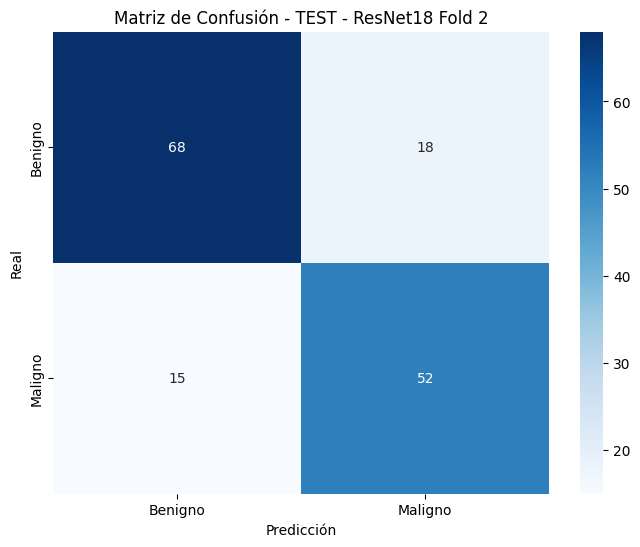


REPORTE: TEST - ResNet18 Fold 2
              precision    recall  f1-score   support

     Benigno       0.82      0.79      0.80        86
     Maligno       0.74      0.78      0.76        67

    accuracy                           0.78       153
   macro avg       0.78      0.78      0.78       153
weighted avg       0.79      0.78      0.78       153

────────────────────────────────────────────────────────────
  Accuracy:           0.7843
  F1 Macro:           0.7819
  Recall Macro:       0.7834
  Cohen's Kappa:      0.5640

>>> DenseNet121 Fold 1


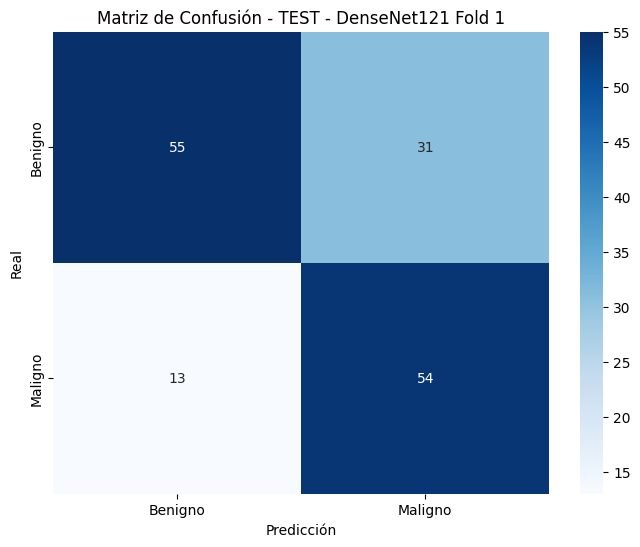


REPORTE: TEST - DenseNet121 Fold 1
              precision    recall  f1-score   support

     Benigno       0.81      0.64      0.71        86
     Maligno       0.64      0.81      0.71        67

    accuracy                           0.71       153
   macro avg       0.72      0.72      0.71       153
weighted avg       0.73      0.71      0.71       153

────────────────────────────────────────────────────────────
  Accuracy:           0.7124
  F1 Macro:           0.7124
  Recall Macro:       0.7228
  Cohen's Kappa:      0.4327

>>> YOLO26x Fold 2


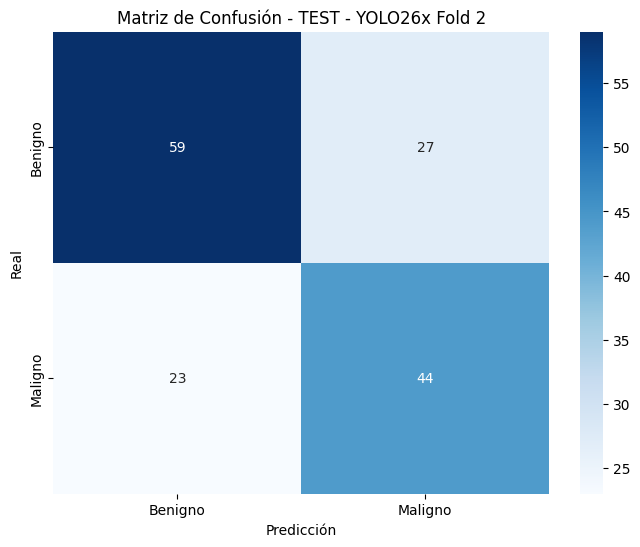


REPORTE: TEST - YOLO26x Fold 2
              precision    recall  f1-score   support

     Benigno       0.72      0.69      0.70        86
     Maligno       0.62      0.66      0.64        67

    accuracy                           0.67       153
   macro avg       0.67      0.67      0.67       153
weighted avg       0.68      0.67      0.67       153

────────────────────────────────────────────────────────────
  Accuracy:           0.6732
  F1 Macro:           0.6700
  Recall Macro:       0.6714
  Cohen's Kappa:      0.3405

>>> Ensemble (R=0.33, D=0.33, Y=0.34)


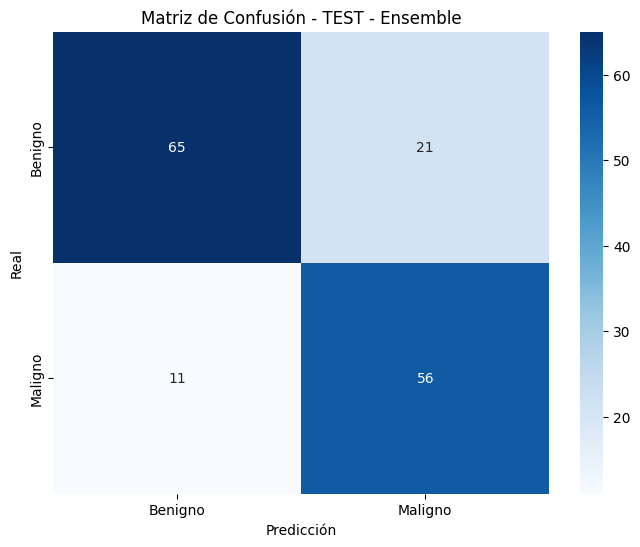


REPORTE: TEST - Ensemble
              precision    recall  f1-score   support

     Benigno       0.86      0.76      0.80        86
     Maligno       0.73      0.84      0.78        67

    accuracy                           0.79       153
   macro avg       0.79      0.80      0.79       153
weighted avg       0.80      0.79      0.79       153

────────────────────────────────────────────────────────────
  Accuracy:           0.7908
  F1 Macro:           0.7901
  Recall Macro:       0.7958
  Cohen's Kappa:      0.5820

COMPARATIVA FINAL - TEST
             F1_macro  Accuracy  Recall_macro  Precision_macro     AUC
ResNet F2      0.7819    0.7843        0.7834           0.7811  0.8223
DenseNet F1    0.7124    0.7124        0.7228           0.7221  0.7690
YOLO F2        0.6700    0.6732        0.6714           0.6696  0.7721
Ensemble       0.7901    0.7908        0.7958           0.7913  0.8598


In [14]:
# ============================================================
# EVALUACIÓN INDIVIDUAL DETALLADA EN TEST
# ============================================================

print("="*70)
print("EVALUACIÓN INDIVIDUAL DETALLADA EN TEST")
print("="*70)

# ResNet
print(f"\n>>> ResNet18 Fold {BEST_FOLD_RESNET}")
mostrar_reporte_completo(y_true_test, y_pred_resnet, classes, f"TEST - ResNet18 Fold {BEST_FOLD_RESNET}")

# DenseNet
print(f"\n>>> DenseNet121 Fold {BEST_FOLD_DENSENET}")
mostrar_reporte_completo(y_true_test, y_pred_densenet, classes, f"TEST - DenseNet121 Fold {BEST_FOLD_DENSENET}")

# YOLO
print(f"\n>>> YOLO26x Fold {BEST_FOLD_YOLO}")
mostrar_reporte_completo(y_true_test, y_pred_yolo, classes, f"TEST - YOLO26x Fold {BEST_FOLD_YOLO}")

# Ensemble
print(f"\n>>> Ensemble (R={w_resnet}, D={w_densenet}, Y={w_yolo})")
mostrar_reporte_completo(y_true_test, preds_ensemble, classes, f"TEST - Ensemble")

# ============================================================
# TABLA COMPARATIVA FINAL
# ============================================================

import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score

def get_all_metrics(y_true, y_pred, y_probs, pos_idx=1):
    fpr, tpr, _ = roc_curve(y_true, y_probs[:, pos_idx])
    return {
        'F1_macro': f1_score(y_true, y_pred, average='macro'),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Recall_macro': recall_score(y_true, y_pred, average='macro'),
        'Precision_macro': precision_score(y_true, y_pred, average='macro'),
        'AUC': auc(fpr, tpr)
    }

tabla_final = pd.DataFrame({
    f'ResNet F{BEST_FOLD_RESNET}': get_all_metrics(y_true_test, y_pred_resnet, probs_resnet),
    f'DenseNet F{BEST_FOLD_DENSENET}': get_all_metrics(y_true_test, y_pred_densenet, probs_densenet),
    f'YOLO F{BEST_FOLD_YOLO}': get_all_metrics(y_true_test, y_pred_yolo, probs_yolo),
    'Ensemble': get_all_metrics(y_true_test, preds_ensemble, probs_ensemble)
}).T

print("\n" + "="*70)
print("COMPARATIVA FINAL - TEST")
print("="*70)
print(tabla_final.round(4).to_string())


## 10. Conclusiones Finales

### Resultados en Test

| Modelo | F1-Macro | AUC ROC | Accuracy | Kappa | Recall Maligno |
|--------|----------|---------|----------|-------|----------------|
| ResNet Fold 2 | 0.7819 | 0.8223 | 78.4% | 0.564 | 78% |
| DenseNet Fold 1 | 0.7124 | 0.7690 | 71.2% | 0.433 | 81% |
| YOLO Fold 2 | 0.6700 | 0.7721 | 67.3% | 0.341 | 66% |
| **Ensemble** | **0.7901** | **0.8598** | **79.1%** | **0.582** | **84%** |

### Lo que aprendimos

**1. El Ensemble funciona:** Combinar los 3 modelos mejora sobre cualquiera individual. El AUC sube a 0.86 y detectamos el 84% de los malignos.

**2. ResNet es el mejor modelo individual:** Simple, estable, y generaliza bien. DenseNet sufre overfitting severo (AUC cae 14% de validación a test).

**3. YOLO no es ideal para clasificación pura:** Diseñado para detección, no aprovecha bien sus capacidades aquí. Aun así, aporta diversidad al ensemble.

**4. El trade-off es aceptable:** El ensemble tiene 11 falsos negativos (malignos no detectados) vs 21 falsos positivos. En diagnóstico médico, preferimos falsas alarmas a casos perdidos.

### Recomendación Final

Usar el **Ensemble** como modelo de producción:
- Mejor capacidad discriminativa (AUC 0.86)
- Mayor sensibilidad (84% recall de malignos)
- Solo 11 casos malignos no detectados de 67

Si se quiere un modelo más simple, **ResNet Fold 2** es una buena alternativa con F1 0.78.